# Analysis for N.Haket's PhD Thesis Chapter 8

This code notebook runs three main experiments, as detailed in chapter 8 of the thesis.



1.   The code calculates four distributional metrics (SelfSim, MEV, Intra-Similarity, Inter-Similarity) for each word and statistically tests whether these metrics vary across the seven taxonomic categories using ANOVA or Kruskal-Wallis tests. It then computes effect sizes (η²) to quantify how much variance in each metric is explained by category membership. Finally, for finer-grained hypotheses, it conducts independent-samples t-tests comparing words grouped by orientation (mind- vs. world-oriented) and abstractness (abstract vs. concrete) to see whether these theoretical distinctions predict systematic differences in distributional behaviour.
2.   The code converts raw participant responses for each word into percentage distributions across four interpretive categories (PAR, SIT, INF, EVA) to allow comparison across words with unequal response counts. It then calculates mean percentages for each category within binary groups (mind- vs. world-oriented; abstract vs. concrete) and applies independent-samples t-tests or Mann-Whitney U tests to assess whether interpretive patterns differ systematically by orientation or abstractness. Finally, it applies Bonferroni correction to control for multiple comparisons and computes effect sizes (Cohen’s d) to evaluate the practical magnitude of observed differences.
3.   I operationalise the distinction between lexical and contextual contributions to interpretation by classifying participant responses into minimal contextual elaboration (PAR) and substantial contextual elaboration (SIT, INF, EVA combined).Using responses from ten target words, I test whether lexical properties systematically influence the distribution of minimal versus substantial elaboration. If lexical meaning strongly constrains interpretation, words should show markedly different distributions; if context dominates, distributions should be relatively uniform. Chi-square tests of independence are used to formally evaluate this hypothesis.



##Loading packages and pre-requisites

In [53]:
# Data manipulation
import pandas as pd
import numpy as np
import os

# Statistics
from scipy import stats
from scipy.stats import (
    shapiro,
    f_oneway,
    kruskal,
    ttest_ind,
    mannwhitneyu,
    chi2_contingency,
    chisquare
)
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.multivariate.manova import MANOVA

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Google Colab & Google Sheets integration
import gspread
from google.colab import auth, drive
from oauth2client.client import GoogleCredentials
from google.auth import default

mount='/content/gdrive'
print("Colab: mounting Google drive on ", mount)

drive.mount(mount)

# Switch to the directory on the Google Drive tschool you want to use
drive_root = mount + "/My Drive/BERT-for-context-main"

# Create drive_root if it doesn't exist
create_drive_root = True
if create_drive_root:
  print("\nColab: making sure ", drive_root, " exists.")
  os.makedirs(drive_root, exist_ok=True)

# Change to the directory
print("\nColab: Changing directory to ", drive_root)
%cd $drive_root



Colab: mounting Google drive on  /content/gdrive
Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).

Colab: making sure  /content/gdrive/My Drive/BERT-for-context-main  exists.

Colab: Changing directory to  /content/gdrive/My Drive/BERT-for-context-main
/content/gdrive/My Drive/BERT-for-context-main


In [54]:
!apt install texlive-fonts-recommended texlive-fonts-extra cm-super dvipng

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
cm-super is already the newest version (0.3.4-17).
dvipng is already the newest version (1.15-1.1).
texlive-fonts-extra is already the newest version (2021.20220204-1).
texlive-fonts-recommended is already the newest version (2021.20220204-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


##Framework Exploration: Distributional Reality

This code takes the summary data generated from the Conceptual Engineering Word Embeddings experiments and performs descriptive and inferential statistical analysis to explore the distributional reality of words across lexical categories (taxonomy) and broader theoretical distinctions (orientation, abstractness).

It includes:

Data Preparation
- Loads summary_table.csv containing all key metrics for words (SelfSim, MEV, intra/inter-group similarity, ARI scores, PCA components, etc.).
- Cleans column names, converts numeric columns to proper numeric types, and ensures categorical variables (taxonomy, orientation, abstract) are correctly set.
- Renames metrics for readability (cosine sim → SelfSim, mev → MEV).

Descriptive Statistics
- Computes and prints summary statistics (mean, median, std, min/max, IQR) for each metric grouped by taxonomy.
- Produces boxplots for each metric by taxonomy to visualize distribution differences.

Normality Testing
- For each metric, tests whether data within each taxonomy category are normally distributed using the Shapiro-Wilk test.
- Normality results determine whether parametric or non-parametric tests should be used.

Statistical Significance Testing Across Taxonomy
- If normality is satisfied: one-way ANOVA is performed across all taxonomy groups, with eta squared (η²) as effect size.
- If normality is violated: Kruskal-Wallis test is performed, with epsilon squared (ε²) as effect size.
- Tests assess whether there are statistically significant differences in metrics across categories.

Broader Theoretical Distinctions
- Creates new variables for orientation (world-oriented vs. mind-oriented) and abstractness (abstract vs. concrete) using mappings from taxonomy categories.
Performs two-group statistical comparisons for each metric:
- If both groups are normally distributed: Welch’s t-test with Cohen’s d for effect size.
- If normality is violated: Mann-Whitney U test with rank-biserial correlation as effect size.
- Produces boxplots for metrics by abstract and orientation groups to visualize differences.



In [55]:
# Path to your CSV file in Google Drive
file_path = '/content/gdrive/MyDrive/lm-conceptual-engineering-main/experiments/summary_table.csv'

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path)
# Display the first 15 rows of the DataFrame
print(df.head(35))


    Unnamed: 0  taxonomy            word  optimal components  \
0            0         1          weight                   2   
1            1         1        pressure                   2   
2            2         1     electricity                   2   
3            3         1     temperature                   2   
4            4         1          energy                   2   
5            5         2           water                   2   
6            6         2          planet                   2   
7            7         2          cancer                   2   
8            8         2         protein                   2   
9            9         2           tiger                   2   
10          10         3          theory                   2   
11          11         3          system                   2   
12          12         3            data                   2   
13          13         3         concept                   2   
14          14         3     information

In [56]:
# Remove columns where the name starts with 'Unnamed'
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Convert all columns to numeric except 'taxonomy' and 'word'
for column in df.columns:
    if column not in ['taxonomy', 'word']:
        df[column] = pd.to_numeric(df[column], errors='coerce')

# Convert 'taxonomy' to categorical
df['taxonomy'] = df['taxonomy'].astype('category')

# Ensure 'word' remains as a string or categorical
df['word'] = df['word'].astype('str')  # or .astype('category') if preferred

df = df.rename(columns={'cosine sim': 'SelfSim'})
df = df.rename(columns={'mev': 'MEV'})

# Display the updated DataFrame
print(df.head(15))


   taxonomy         word  optimal components  optimal clusters  best_score  \
0         1       weight                   2                 2      0.7507   
1         1     pressure                   2                 2      0.8212   
2         1  electricity                   2                 2      0.5399   
3         1  temperature                   2                 3      0.6366   
4         1       energy                   2                 3      0.6855   
5         2        water                   2                 2      0.5853   
6         2       planet                   2                 4      0.7128   
7         2       cancer                   2                 3      0.6953   
8         2      protein                   2                 4      0.5126   
9         2        tiger                   2                 2      0.5913   
10        3       theory                   2                 3      0.8467   
11        3       system                   2                 3  

###Plots of descriptive statistics per category per metric

Descriptive Statistics for SelfSim by taxonomy:

          count   mean    std    min    25%    50%    75%    max
taxonomy                                                        
1        5.0000 0.2954 0.0461 0.2434 0.2495 0.3107 0.3333 0.3402
2        5.0000 0.3349 0.0450 0.2788 0.3054 0.3349 0.3631 0.3923
3        5.0000 0.2498 0.0420 0.2168 0.2197 0.2279 0.2707 0.3142
4        5.0000 0.2675 0.0469 0.1907 0.2651 0.2806 0.2841 0.3169
5        5.0000 0.3180 0.0358 0.2825 0.2978 0.3083 0.3255 0.3756
6        5.0000 0.3194 0.0149 0.2994 0.3124 0.3202 0.3254 0.3394
7        5.0000 0.3031 0.0392 0.2452 0.2956 0.2957 0.3354 0.3436


/tmp/ipython-input-2336961745.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  desc_stats = df.groupby(taxonomy)[col].describe()
/tmp/ipython-input-2336961745.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=taxonomy, y=col, data=df, palette='viridis')


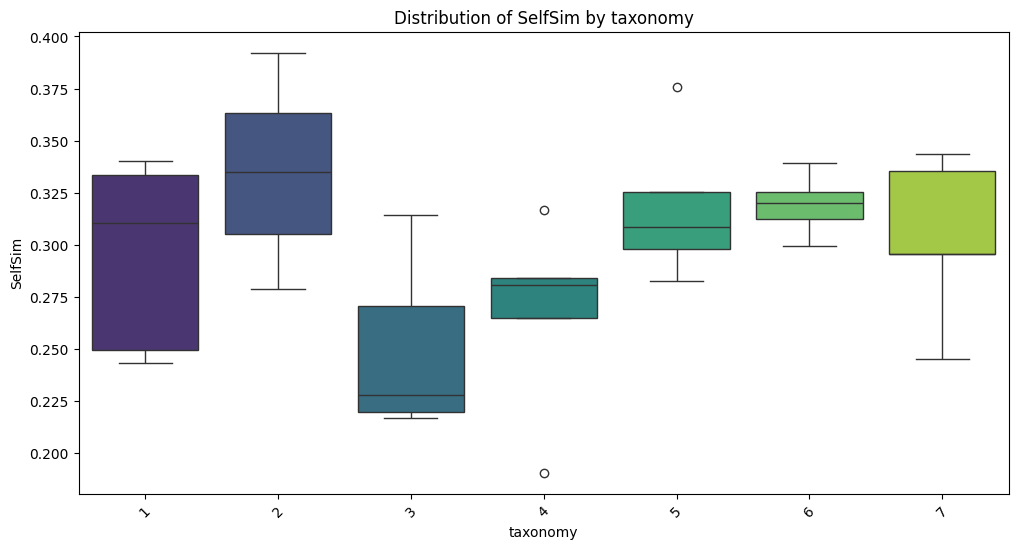

/tmp/ipython-input-2336961745.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  desc_stats = df.groupby(taxonomy)[col].describe()
/tmp/ipython-input-2336961745.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=taxonomy, y=col, data=df, palette='viridis')


Descriptive Statistics for MEV by taxonomy:

          count   mean    std    min    25%    50%    75%    max
taxonomy                                                        
1        5.0000 0.1157 0.0411 0.0661 0.0933 0.1083 0.1380 0.1728
2        5.0000 0.0891 0.0180 0.0678 0.0721 0.0958 0.1047 0.1052
3        5.0000 0.0714 0.0334 0.0269 0.0585 0.0730 0.0798 0.1187
4        5.0000 0.0965 0.0270 0.0718 0.0807 0.0815 0.1126 0.1361
5        5.0000 0.0613 0.0256 0.0396 0.0454 0.0484 0.0719 0.1014
6        5.0000 0.0752 0.0350 0.0471 0.0532 0.0577 0.0859 0.1319
7        5.0000 0.0844 0.0324 0.0435 0.0797 0.0815 0.0830 0.1344


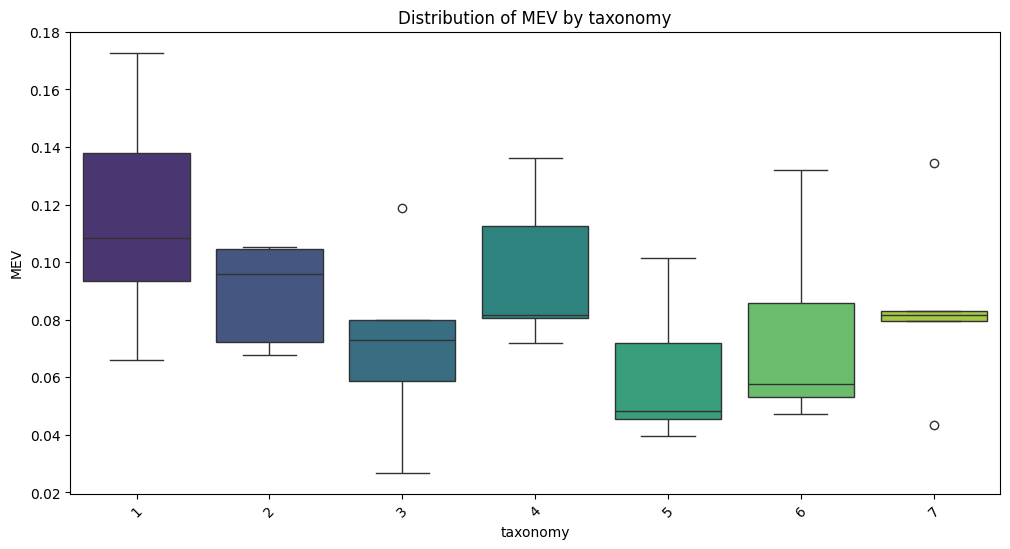

/tmp/ipython-input-2336961745.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  desc_stats = df.groupby(taxonomy)[col].describe()
/tmp/ipython-input-2336961745.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=taxonomy, y=col, data=df, palette='viridis')


Descriptive Statistics for 2D intra sim by taxonomy:

          count   mean    std    min    25%    50%    75%    max
taxonomy                                                        
1        5.0000 0.7935 0.1032 0.6119 0.8156 0.8337 0.8395 0.8668
2        5.0000 0.8134 0.0982 0.7003 0.7181 0.8593 0.8684 0.9208
3        5.0000 0.8463 0.0604 0.7635 0.8190 0.8537 0.8683 0.9267
4        5.0000 0.8113 0.0957 0.7063 0.7112 0.8540 0.8754 0.9098
5        5.0000 0.8148 0.0793 0.7195 0.7541 0.8311 0.8504 0.9190
6        5.0000 0.7388 0.0645 0.6412 0.7318 0.7343 0.7702 0.8167
7        5.0000 0.8041 0.0561 0.7407 0.7629 0.7929 0.8570 0.8667


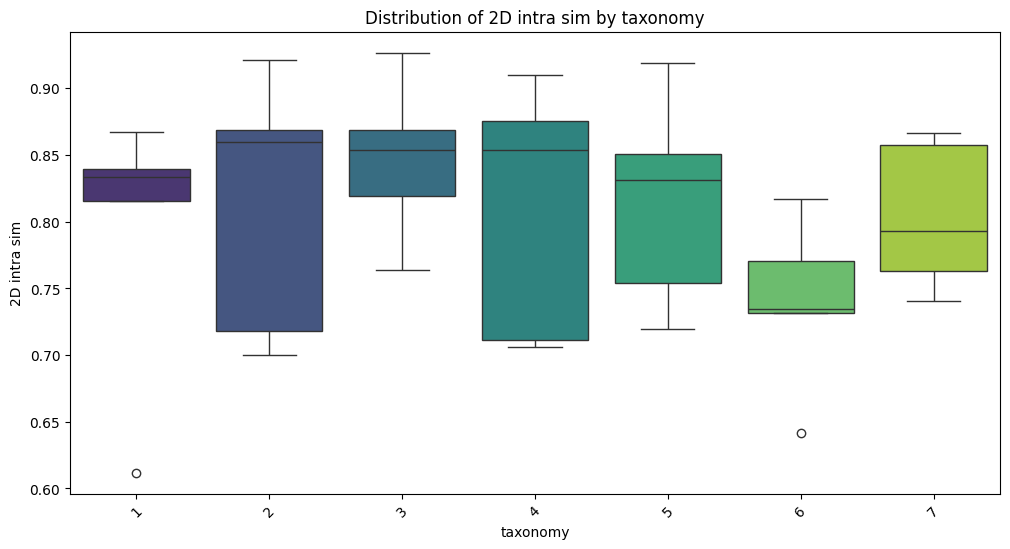

/tmp/ipython-input-2336961745.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  desc_stats = df.groupby(taxonomy)[col].describe()
/tmp/ipython-input-2336961745.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=taxonomy, y=col, data=df, palette='viridis')


Descriptive Statistics for 2D inter sim by taxonomy:

          count   mean    std    min    25%    50%    75%    max
taxonomy                                                        
1        5.0000 0.2576 0.0823 0.1567 0.1810 0.2992 0.3187 0.3325
2        5.0000 0.3056 0.0421 0.2514 0.2777 0.3147 0.3245 0.3598
3        5.0000 0.2882 0.0378 0.2291 0.2781 0.3013 0.3029 0.3298
4        5.0000 0.3287 0.0584 0.2816 0.2824 0.2984 0.3721 0.4092
5        5.0000 0.3438 0.0587 0.2819 0.3256 0.3290 0.3416 0.4408
6        5.0000 0.2803 0.0432 0.2245 0.2663 0.2667 0.3059 0.3378
7        5.0000 0.3639 0.0719 0.2533 0.3451 0.3677 0.4166 0.4367


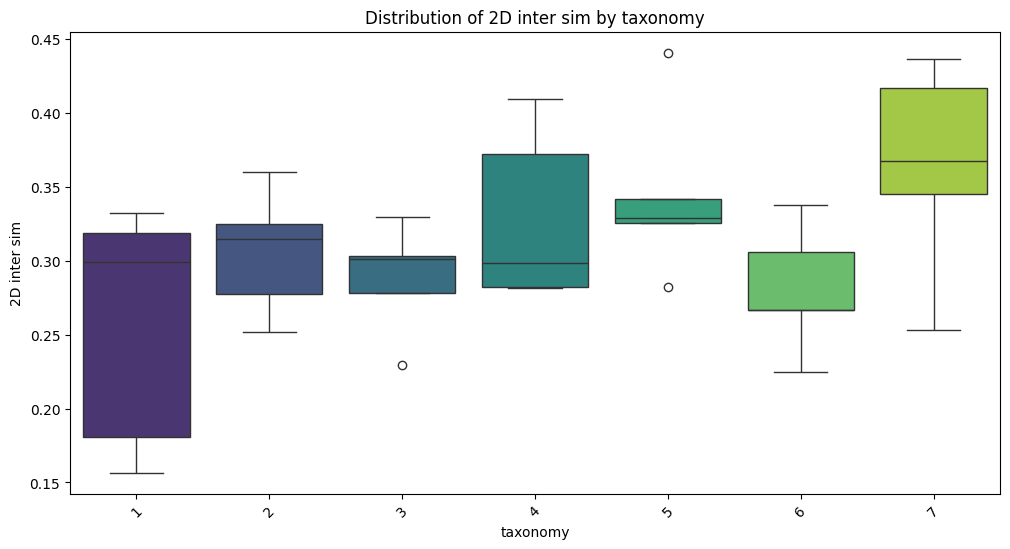

In [57]:
# Numerical columns and taxonomy
numerical_columns = ['SelfSim', 'MEV', '2D intra sim', '2D inter sim']
taxonomy = 'taxonomy'

# Plotting each numerical column separately
for col in numerical_columns:
    # Calculate descriptive statistics
    desc_stats = df.groupby(taxonomy)[col].describe()
    print(f"Descriptive Statistics for {col} by {taxonomy}:\n")
    print(desc_stats)

    # Plot Distribution by Taxonomy (Box Plot)
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=taxonomy, y=col, data=df, palette='viridis')
    plt.title(f'Distribution of {col} by {taxonomy}')
    plt.xticks(rotation=45)
    plt.show()


###Statistical significance analysis across all metrics across all categories

In [58]:
# Define numerical columns
numerical_columns = ['SelfSim', 'MEV', '2D intra sim', '2D inter sim']

# Define features and target
X = df[numerical_columns]
y = df['taxonomy']

# Prepare normality results
normality_results = {}

# Perform normality test for each feature
for feature in numerical_columns:
    # Group data by category
    groups = [X[y == category][feature] for category in y.unique()]

    # Check variance and perform Shapiro-Wilk test if appropriate
    normality_passed = True
    for group in groups:
        if len(group) > 1:  # Ensure group size is sufficient
            if group.var() == 0:  # Check for zero variance
                print(f"Warning: Zero variance in group for feature '{feature}'")
                normality_passed = False
                break
            else:
                stat, p_value = shapiro(group)
                if p_value <= 0.05:
                    normality_passed = False
                    break
        else:
            normality_passed = False
            break

    normality_results[feature] = {'Normality Passed': normality_passed}

# Convert to DataFrame
normality_df = pd.DataFrame.from_dict(normality_results, orient='index')
print("Normality Test Results:\n", normality_df)


Normality Test Results:
               Normality Passed
SelfSim                   True
MEV                       True
2D intra sim             False
2D inter sim              True


In [59]:
# Define features and target
X = df[numerical_columns]
y = df['taxonomy']

# Prepare results storage
results = []

# Perform ANOVA or Kruskal-Wallis for each feature based on normality results
for feature in numerical_columns:
    # Group data by category
    groups = [X[y == category][feature].dropna() for category in y.unique()]
    k = len(groups)
    n_total = sum(len(g) for g in groups)

    if normality_results[feature]['Normality Passed']:
        # Perform ANOVA
        f_stat, p_value = f_oneway(*groups)

        # Compute eta squared as effect size
        grand_mean = pd.concat(groups).mean()
        ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
        ss_total = sum(((g - grand_mean) ** 2).sum() for g in groups)
        eta_squared = ss_between / ss_total if ss_total != 0 else 0

        results.append({
            'Feature': feature,
            'Test': 'ANOVA',
            'Test Statistic': f_stat,
            'p-value': p_value,
            'Effect Size (η²)': eta_squared,
            'Effect Size (ε²)': np.nan
        })
    else:
        # Perform Kruskal-Wallis test
        h_stat, p_value = kruskal(*groups)

        # Use eta squared for Kruskal-Wallis (more robust than epsilon squared)
        eta_squared_kw = (h_stat - k + 1) / (n_total - 1) if n_total > 1 else 0
        eta_squared_kw = max(0, eta_squared_kw)  # Ensure non-negative

        results.append({
            'Feature': feature,
            'Test': 'Kruskal-Wallis',
            'Test Statistic': h_stat,
            'p-value': p_value,
            'Effect Size (η²)': np.nan,
            'Effect Size (ε²)': eta_squared_kw
        })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Mark significance
results_df['Significant (p < .05)'] = results_df['p-value'] < 0.05

# Display
pd.set_option('display.float_format', '{:.4f}'.format)
print("Statistical Test Results:\n")
print(results_df)

Statistical Test Results:

        Feature            Test  Test Statistic  p-value  Effect Size (η²)  \
0       SelfSim           ANOVA          2.8784   0.0259            0.3815   
1           MEV           ANOVA          1.6628   0.1673            0.2627   
2  2D intra sim  Kruskal-Wallis          4.8038   0.5692               NaN   
3  2D inter sim           ANOVA          2.0806   0.0877            0.3084   

   Effect Size (ε²)  Significant (p < .05)  
0               NaN                   True  
1               NaN                  False  
2            0.0000                  False  
3               NaN                  False  


###Testing statistical significance of Broader Theoretical Distinctions: Orientation and Abstractness

In [60]:
# Define the mappings for the new categories
orientation_mapping = {
    1: 'world-oriented',
    2: 'world-oriented',
    3: 'mind-oriented',
    4: 'mind-oriented',
    5: 'mind-oriented',
    6: 'mind-oriented',
    7: 'mind-oriented'
}

abstract_mapping = {
    1: 'abstract',
    2: 'concrete',
    3: 'abstract',
    4: 'abstract',
    5: 'abstract',
    6: 'concrete',
    7: 'concrete'
}

# Create new columns based on the mappings
df['orientation'] = df['taxonomy'].map(orientation_mapping)
df['abstract'] = df['taxonomy'].map(abstract_mapping)


df['orientation'] = df['orientation'].astype('category')
df['abstract'] = df['abstract'].astype('category')

print(df)


   taxonomy            word  optimal components  optimal clusters  best_score  \
0         1          weight                   2                 2      0.7507   
1         1        pressure                   2                 2      0.8212   
2         1     electricity                   2                 2      0.5399   
3         1     temperature                   2                 3      0.6366   
4         1          energy                   2                 3      0.6855   
5         2           water                   2                 2      0.5853   
6         2          planet                   2                 4      0.7128   
7         2          cancer                   2                 3      0.6953   
8         2         protein                   2                 4      0.5126   
9         2           tiger                   2                 2      0.5913   
10        3          theory                   2                 3      0.8467   
11        3          system 

In [61]:
numerical_columns = ['SelfSim', 'MEV', '2D intra sim', '2D inter sim']

def check_normality(data):
    """Check if the data is normally distributed using the Shapiro-Wilk test."""
    stat, p_value = shapiro(data)
    return p_value > 0.05  # Return True if data is normally distributed

def compute_cohens_d(x, y):
    """Compute Cohen's d for independent samples."""
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(((nx - 1) * x.std(ddof=1) ** 2 + (ny - 1) * y.std(ddof=1) ** 2) / (nx + ny - 2))
    return (x.mean() - y.mean()) / pooled_std

def compute_rank_biserial(u_stat, n1, n2):
    """Compute rank-biserial correlation from Mann-Whitney U statistic."""
    return 1 - (2 * u_stat) / (n1 * n2)

def perform_t_or_mannwhitney(target_column, df, numerical_columns):
    print(f"Performing t-test / Mann-Whitney for {target_column}...\n")

    results = {}
    categories = df[target_column].dropna().unique()
    if len(categories) != 2:
        raise ValueError(f"{target_column} does not have exactly two categories.")

    group1, group2 = categories

    for feature in numerical_columns:
        data1 = df[df[target_column] == group1][feature].dropna()
        data2 = df[df[target_column] == group2][feature].dropna()

        normal1 = check_normality(data1)
        normal2 = check_normality(data2)

        if normal1 and normal2:
            stat, p_value = ttest_ind(data1, data2, equal_var=False)
            effect_size = compute_cohens_d(data1, data2)
            test_used = 't-test'
        else:
            stat, p_value = mannwhitneyu(data1, data2, alternative='two-sided')
            effect_size = compute_rank_biserial(stat, len(data1), len(data2))
            test_used = 'Mann-Whitney'

        results[feature] = {
            'p-value': p_value,
            'Test': test_used,
            f'{group1} Mean': data1.mean(),
            f'{group2} Mean': data2.mean(),
            'Effect Size': effect_size
        }

    results_df = pd.DataFrame.from_dict(results, orient='index')
    results_df.reset_index(inplace=True)
    results_df.rename(columns={'index': 'Feature'}, inplace=True)
    results_df['Significant'] = results_df['p-value'] < 0.05

    print(f"Test Results for {target_column}:\n", results_df)

    return results_df


####Abstractness

In [62]:
results_abstract = perform_t_or_mannwhitney('abstract', df, numerical_columns)

Performing t-test / Mann-Whitney for abstract...

Test Results for abstract:
         Feature  p-value    Test  abstract Mean  concrete Mean  Effect Size  \
0       SelfSim   0.0140  t-test         0.2827         0.3191      -0.8499   
1           MEV   0.7613  t-test         0.0862         0.0829       0.1005   
2  2D intra sim   0.2604  t-test         0.8165         0.7854       0.3887   
3  2D inter sim   0.5862  t-test         0.3046         0.3166      -0.1860   

   Significant  
0         True  
1        False  
2        False  
3        False  


/tmp/ipython-input-675800057.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='taxonomy', y='SelfSim', data=df, order=taxonomy_order, palette=palette)


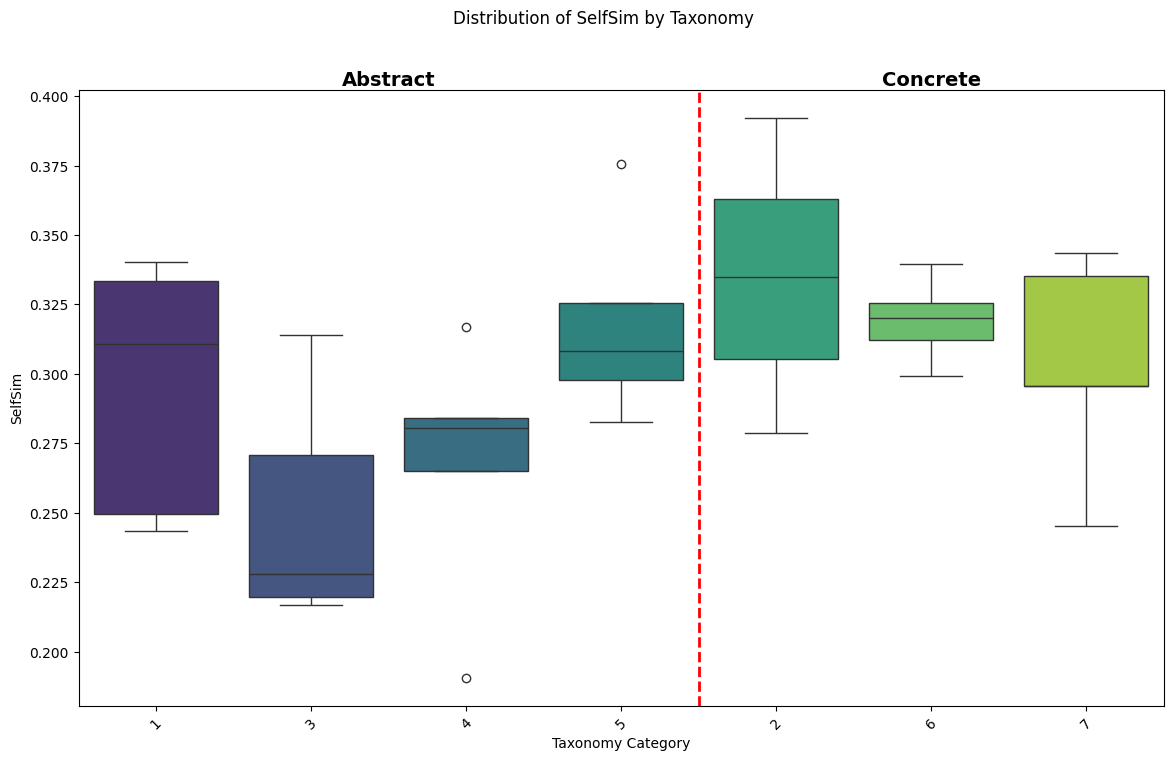

In [63]:
# Define the taxonomy categories for each group
abstract_categories = [1, 3, 4, 5]
concrete_categories = [2, 6, 7]

# Ensure taxonomy column is treated as categorical with proper ordering
taxonomy_order = abstract_categories + concrete_categories

# Define color palette
palette = sns.color_palette('viridis', n_colors=len(taxonomy_order))

# Plot Distribution by Taxonomy (Box Plot)
plt.figure(figsize=(14, 8))
ax = sns.boxplot(x='taxonomy', y='SelfSim', data=df, order=taxonomy_order, palette=palette)

# Add vertical separator between abstract and concrete
separator_x = len(abstract_categories) - 0.5
plt.axvline(x=separator_x, color='red', linestyle='--', linewidth=2, label='Separator')

# Add group labels
plt.text(separator_x - len(abstract_categories)/2, df['SelfSim'].max() + 0.01, 'Abstract',
         ha='center', va='bottom', fontsize=14, color='black', weight='bold')
plt.text(separator_x + len(concrete_categories)/2, df['SelfSim'].max() + 0.01, 'Concrete',
         ha='center', va='bottom', fontsize=14, color='black', weight='bold')

# Customize plot
plt.suptitle('Distribution of SelfSim by Taxonomy')
plt.xlabel('Taxonomy Category')
plt.ylabel('SelfSim')
plt.xticks(rotation=45)

# Show the plot
plt.show()


In [64]:
# Function to calculate summary statistics for each feature (SelfSim, MEV, Inter, Intra)
def calculate_summary_statistics(df, numerical_columns):
    summary_stats_dict = {}

    for feature in numerical_columns:
        # Filter data into two groups based on the 'abstract' column (Abstract vs. Concrete)
        abstract_df = df[df['abstract'] == 'abstract']
        concrete_df = df[df['abstract'] == 'concrete']

        # Calculate summary statistics for both Abstract and Concrete groups
        summary_stats = {
            'Mean': [abstract_df[feature].mean(), concrete_df[feature].mean()],
            'Median': [abstract_df[feature].median(), concrete_df[feature].median()],
            'Std Dev': [abstract_df[feature].std(), concrete_df[feature].std()],
            'Count': [abstract_df[feature].count(), concrete_df[feature].count()],
            'Max': [abstract_df[feature].max(), concrete_df[feature].max()],
            'Min': [abstract_df[feature].min(), concrete_df[feature].min()],
            'Range': [abstract_df[feature].max() - abstract_df[feature].min(), concrete_df[feature].max() - concrete_df[feature].min()],
            'IQR': [abstract_df[feature].quantile(0.75) - abstract_df[feature].quantile(0.25),
                    concrete_df[feature].quantile(0.75) - concrete_df[feature].quantile(0.25)]
        }

        # Convert the summary stats dictionary into a DataFrame with Abstract and Concrete as rows
        summary_stats_df = pd.DataFrame(summary_stats, index=['Abstract', 'Concrete'])
        summary_stats_dict[feature] = summary_stats_df

    return summary_stats_dict

# Numerical columns (adjust based on your data)
numerical_columns = ['SelfSim', 'MEV', '2D intra sim', '2D inter sim']  # Adjust to your actual numerical columns

# Calculate the summary statistics for all numerical columns
summary_statistics = calculate_summary_statistics(df, numerical_columns)

# Display summary statistics for each feature in a separate table
for feature, stats_df in summary_statistics.items():
    print(f"Summary Statistics for {feature}:\n")
    display(stats_df)
    print("\n")


Summary Statistics for SelfSim:



,Mean,Median,Std Dev,Count,Max,Min,Range,IQR
Abstract,0.2827,0.2833,0.0476,20,0.3756,0.1907,0.1849,0.0668
Concrete,0.3191,0.3202,0.0355,15,0.3923,0.2452,0.1471,0.0398




Summary Statistics for MEV:



,Mean,Median,Std Dev,Count,Max,Min,Range,IQR
Abstract,0.0862,0.0803,0.0369,20,0.1728,0.0269,0.1459,0.0452
Concrete,0.0829,0.0815,0.0279,15,0.1344,0.0435,0.0909,0.0375




Summary Statistics for 2D intra sim:



,Mean,Median,Std Dev,Count,Max,Min,Range,IQR
Abstract,0.8165,0.8366,0.0815,20,0.9267,0.6119,0.3149,0.1060
Concrete,0.7854,0.7702,0.0776,15,0.9208,0.6412,0.2795,0.1251




Summary Statistics for 2D inter sim:



,Mean,Median,Std Dev,Count,Max,Min,Range,IQR
Abstract,0.3046,0.3021,0.0662,20,0.4408,0.1567,0.2841,0.0486
Concrete,0.3166,0.3147,0.0619,15,0.4367,0.2245,0.2122,0.0859


/tmp/ipython-input-234262726.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='abstract', y=feature, data=df, palette=palette, ax=ax)
/tmp/ipython-input-234262726.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='abstract', y=feature, data=df, palette=palette, ax=ax)
/tmp/ipython-input-234262726.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='abstract', y=feature, data=df, palette=palette, ax=ax)
/tmp/ipython-input-234262726.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remove

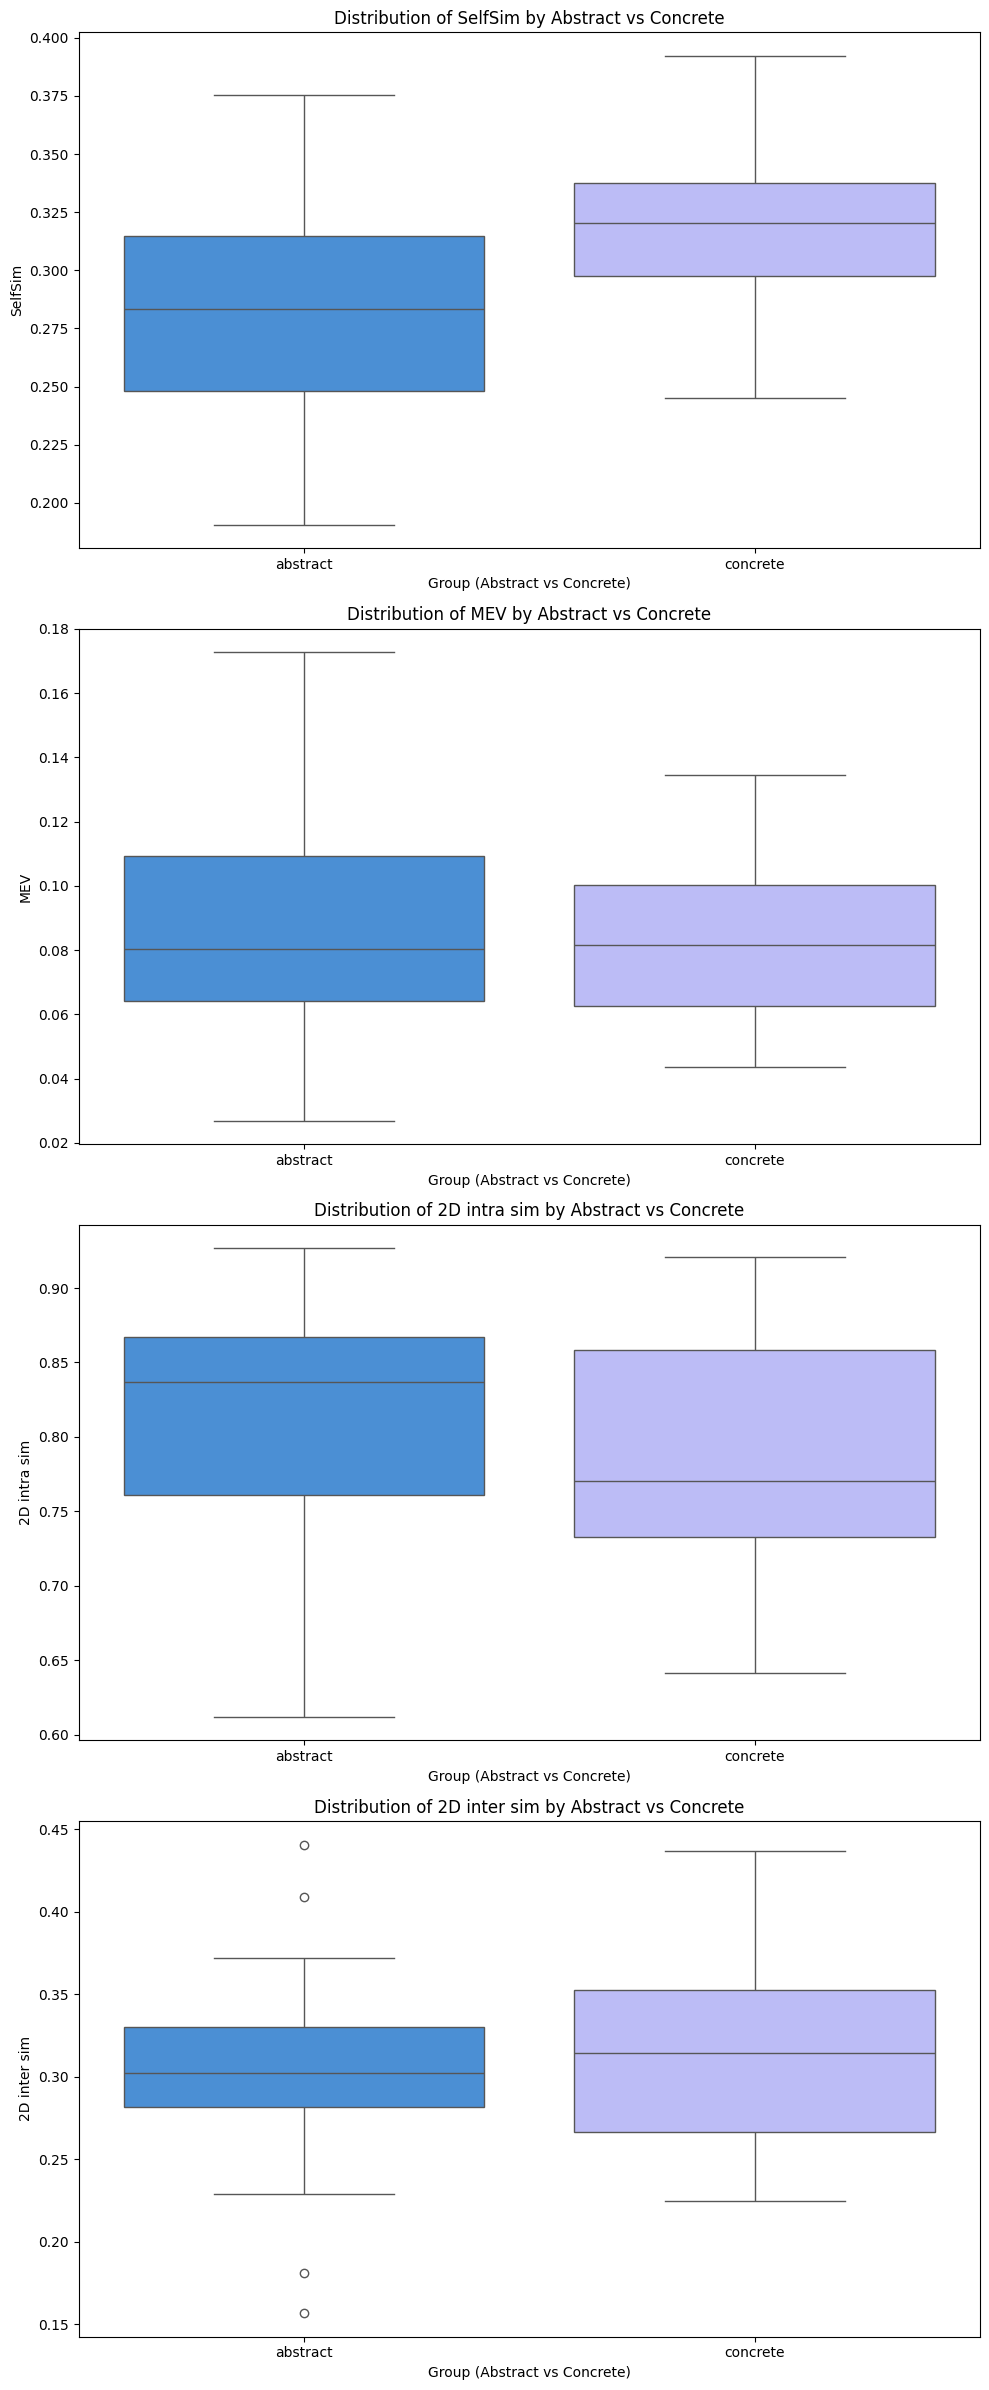

In [65]:
# Function to plot box plots for each feature (SelfSim, MEV, Inter, Intra)
def plot_box_plots(df, numerical_columns):
    # Set up the color palette for Abstract and Concrete
    palette = {'abstract': '#348feb', 'concrete': '#b3b3ff'}

    # Create subplots (one for each feature)
    fig, axes = plt.subplots(len(numerical_columns), 1, figsize=(10, 6 * len(numerical_columns)))
    if len(numerical_columns) == 1:
        axes = [axes]  # Ensure axes is always iterable

    for idx, feature in enumerate(numerical_columns):
        ax = axes[idx]

        # Plotting the boxplot for each feature
        sns.boxplot(x='abstract', y=feature, data=df, palette=palette, ax=ax)

        # Title and labels
        ax.set_title(f'Distribution of {feature} by Abstract vs Concrete')
        ax.set_xlabel('Group (Abstract vs Concrete)')
        ax.set_ylabel(feature)

    plt.tight_layout()
    plt.show()

# Plot box plots for each feature (SelfSim, MEV, Inter, Intra)
plot_box_plots(df, numerical_columns)


####Orientation

In [66]:
results_abstract = perform_t_or_mannwhitney('orientation', df, numerical_columns)

Performing t-test / Mann-Whitney for orientation...

Test Results for orientation:
         Feature  p-value    Test  world-oriented Mean  mind-oriented Mean  \
0       SelfSim   0.1967  t-test               0.3152              0.2915   
1           MEV   0.0595  t-test               0.1024              0.0778   
2  2D intra sim   0.9914  t-test               0.8034              0.8031   
3  2D inter sim   0.1255  t-test               0.2816              0.3210   

   Effect Size  Significant  
0       0.5200        False  
1       0.7853        False  
2       0.0046        False  
3      -0.6343        False  


/tmp/ipython-input-2468243828.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='taxonomy', y='MEV', data=df, order=taxonomy_order, palette=palette)


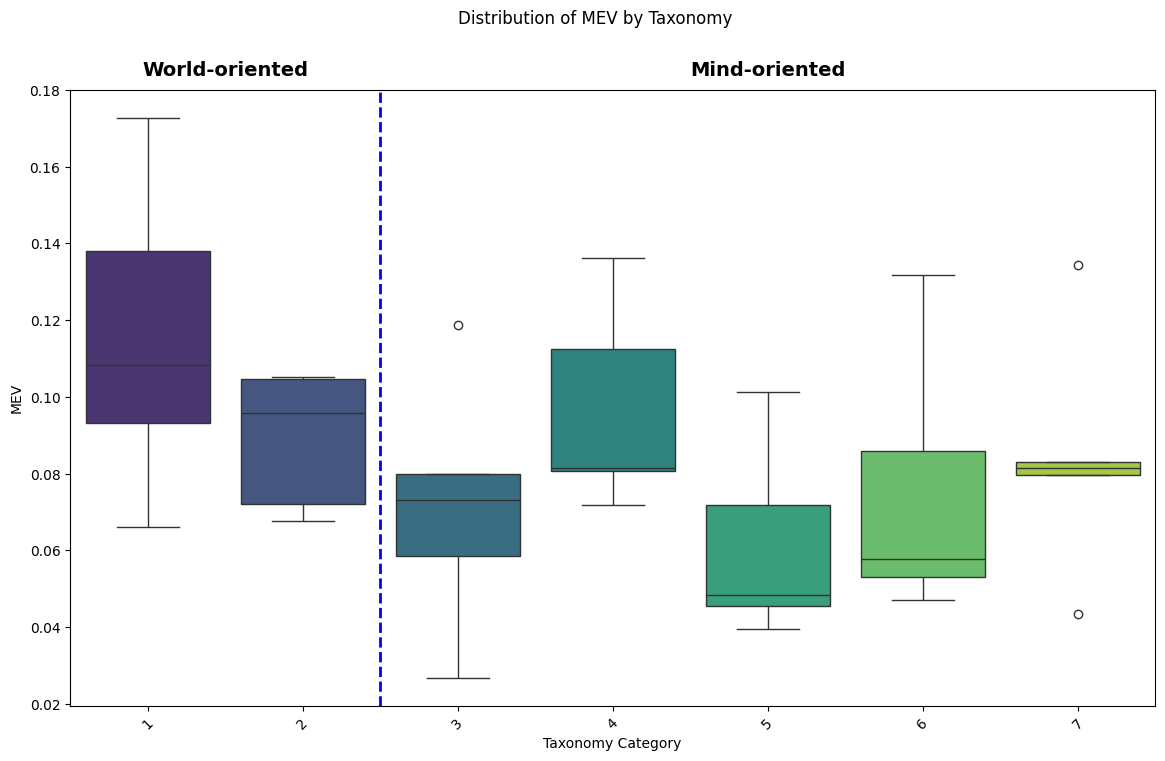

In [67]:
# Define world-oriented and mind-oriented categories
world_oriented_categories = [1, 2]
mind_oriented_categories = [3, 4, 5, 6, 7]

# Explicitly define the taxonomy order
taxonomy_order = world_oriented_categories + mind_oriented_categories

# Define color palette
palette = sns.color_palette('viridis', n_colors=len(taxonomy_order))

# Plot Distribution by Taxonomy with Orientation grouping
plt.figure(figsize=(14, 8))
ax = sns.boxplot(x='taxonomy', y='MEV', data=df, order=taxonomy_order, palette=palette)

# Add vertical line to separate world-oriented and mind-oriented groups
separator_x = len(world_oriented_categories) - 0.5  # The x position to add the separator
plt.axvline(x=separator_x, color='blue', linestyle='--', linewidth=2, label='Separator')

# Add labels for orientation groups
plt.text(separator_x - len(world_oriented_categories)/2, df['MEV'].max() + 0.01, 'World-oriented',
         ha='center', va='bottom', fontsize=14, color='black', weight='bold')
plt.text(separator_x + len(mind_oriented_categories)/2, df['MEV'].max() + 0.01, 'Mind-oriented',
         ha='center', va='bottom', fontsize=14, color='black', weight='bold')

# Customize plot
plt.suptitle('Distribution of MEV by Taxonomy')
plt.xlabel('Taxonomy Category')
plt.ylabel('MEV')
plt.xticks(rotation=45)

# Show the plot
plt.show()


In [68]:
# Function to calculate summary statistics for each feature (SelfSim, MEV, Inter, Intra)
def calculate_summary_statistics(df, numerical_columns):
    summary_stats_dict = {}

    for feature in numerical_columns:
        # Filter data into two groups based on the orientation
        mind_df = df[df['orientation'] == 'mind-oriented']
        world_df = df[df['orientation'] == 'world-oriented']

        # Calculate summary statistics for both orientation
        summary_stats = {
            'Mean': [mind_df[feature].mean(), world_df[feature].mean()],
            'Median': [mind_df[feature].median(), world_df[feature].median()],
            'Std Dev': [mind_df[feature].std(), world_df[feature].std()],
            'Count': [mind_df[feature].count(), world_df[feature].count()],
            'Max': [mind_df[feature].max(), world_df[feature].max()],
            'Min': [mind_df[feature].min(), world_df[feature].min()],
            'Range': [mind_df[feature].max() - mind_df[feature].min(), world_df[feature].max() - world_df[feature].min()],
            'IQR': [mind_df[feature].quantile(0.75) - mind_df[feature].quantile(0.25),
                    world_df[feature].quantile(0.75) - world_df[feature].quantile(0.25)]
        }

        # Convert the summary stats dictionary into a DataFrame with orientation as rows
        summary_stats_df = pd.DataFrame(summary_stats, index=['mind-oriented', 'world-oriented'])
        summary_stats_dict[feature] = summary_stats_df

    return summary_stats_dict

# Numerical columns (adjust based on your data)
numerical_columns = ['SelfSim', 'MEV', '2D intra sim', '2D inter sim']  # Adjust to your actual numerical columns

# Calculate the summary statistics for all numerical columns
summary_statistics = calculate_summary_statistics(df, numerical_columns)

# Display summary statistics for each feature in a separate table
for feature, stats_df in summary_statistics.items():
    print(f"Summary Statistics for {feature}:\n")
    display(stats_df)
    print("\n")


Summary Statistics for SelfSim:



,Mean,Median,Std Dev,Count,Max,Min,Range,IQR
mind-oriented,0.2915,0.2978,0.0445,25,0.3756,0.1907,0.1849,0.0495
world-oriented,0.3152,0.3220,0.0477,10,0.3923,0.2434,0.1489,0.0534




Summary Statistics for MEV:



,Mean,Median,Std Dev,Count,Max,Min,Range,IQR
mind-oriented,0.0778,0.0797,0.0307,25,0.1361,0.0269,0.1092,0.0328
world-oriented,0.1024,0.1002,0.0331,10,0.1728,0.0661,0.1067,0.0302




Summary Statistics for 2D intra sim:



,Mean,Median,Std Dev,Count,Max,Min,Range,IQR
mind-oriented,0.8031,0.8167,0.0755,25,0.9267,0.6412,0.2855,0.1164
world-oriented,0.8034,0.8366,0.0955,10,0.9208,0.6119,0.3089,0.1224




Summary Statistics for 2D inter sim:



,Mean,Median,Std Dev,Count,Max,Min,Range,IQR
mind-oriented,0.3210,0.3059,0.0602,25,0.4408,0.2245,0.2163,0.0634
world-oriented,0.2816,0.3069,0.0666,10,0.3598,0.1567,0.2031,0.0651


/tmp/ipython-input-346961264.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='orientation', y=feature, data=df, palette=palette, ax=ax)
/tmp/ipython-input-346961264.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='orientation', y=feature, data=df, palette=palette, ax=ax)
/tmp/ipython-input-346961264.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='orientation', y=feature, data=df, palette=palette, ax=ax)
/tmp/ipython-input-346961264.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will 

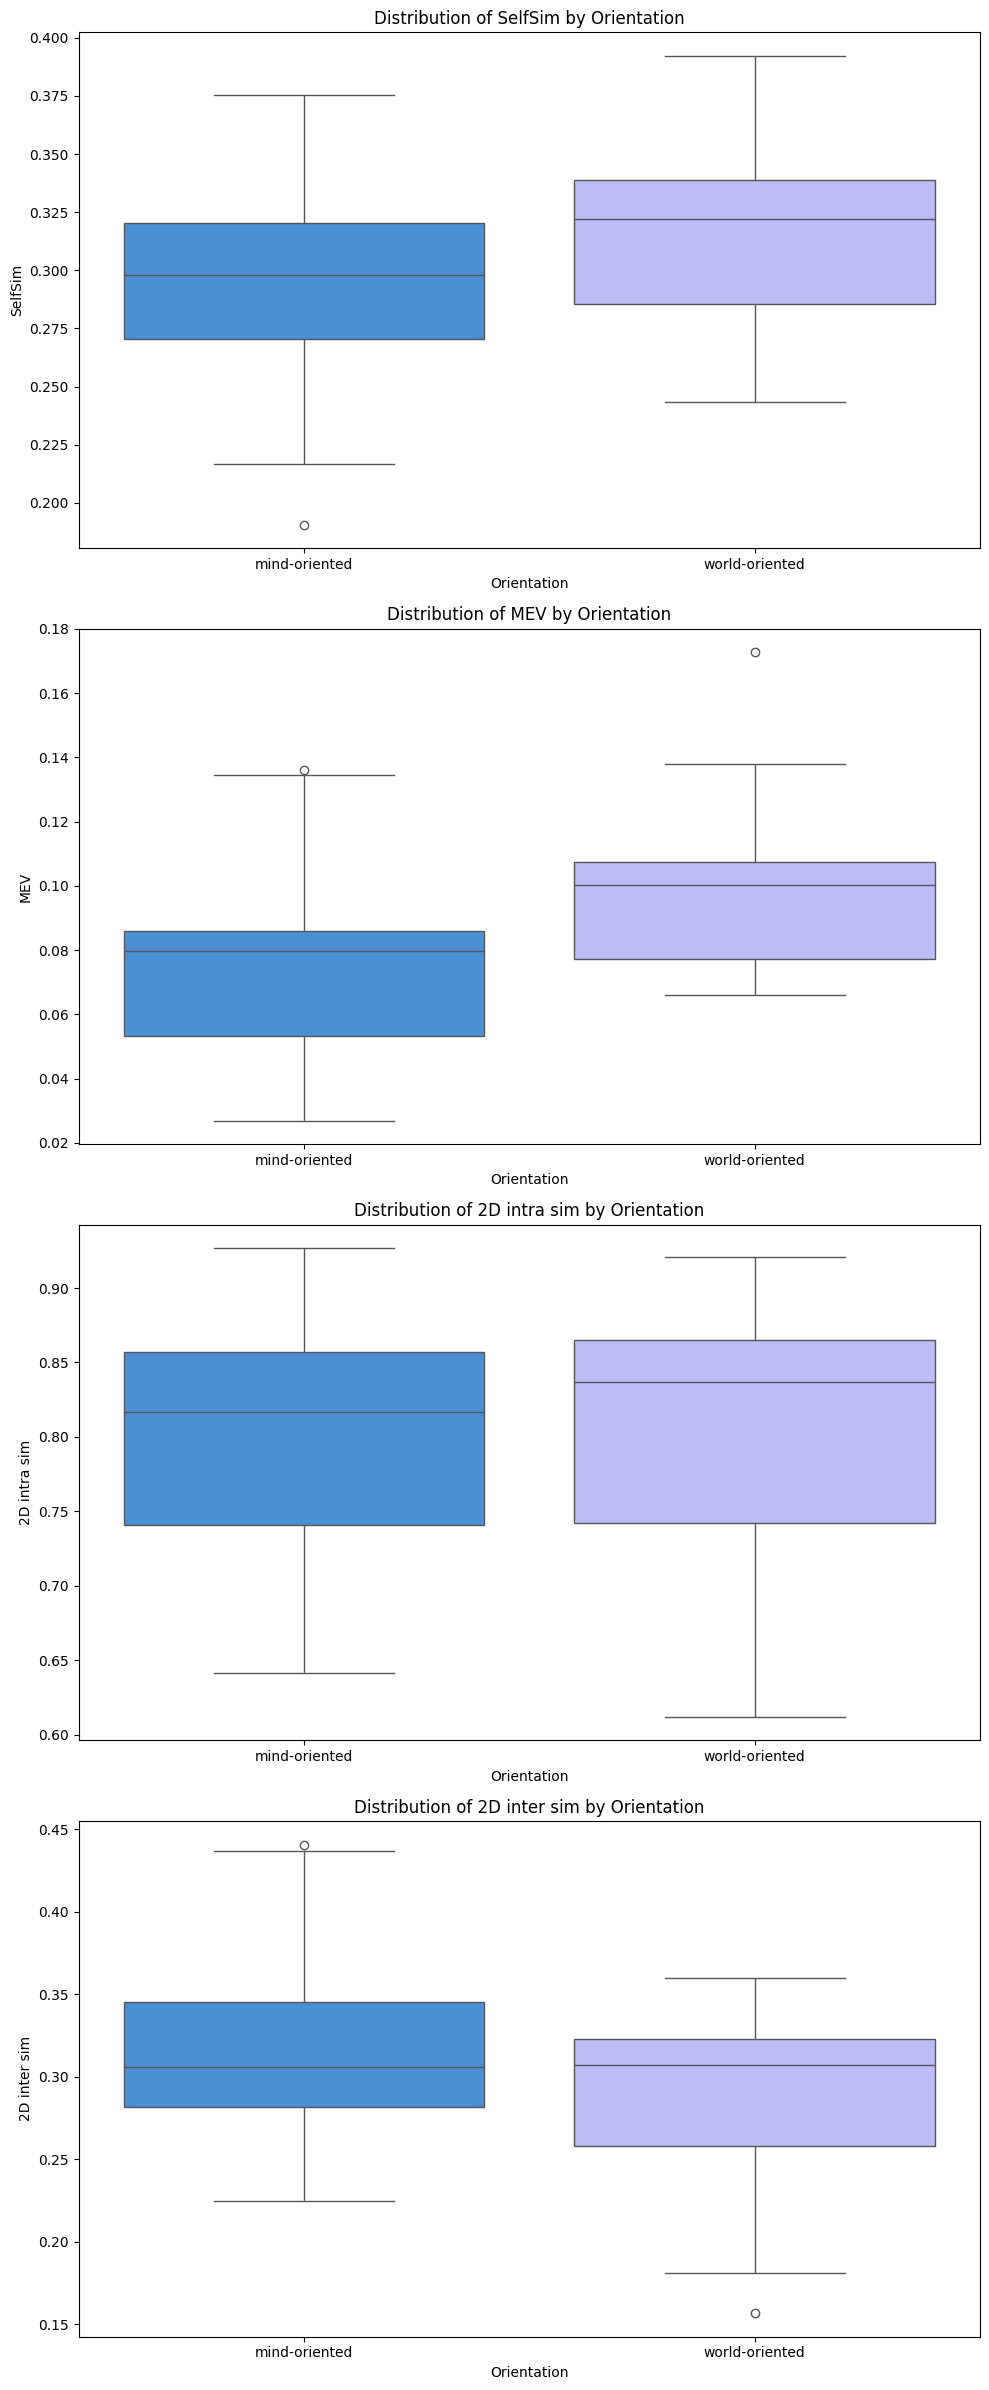

In [69]:
# Function to plot box plots for each feature (SelfSim, MEV, Inter, Intra)
def plot_box_plots(df, numerical_columns):
    # Set up the color palette for Abstract and Concrete
    palette = {'mind-oriented': '#348feb', 'world-oriented': '#b3b3ff'}

    # Create subplots (one for each feature)
    fig, axes = plt.subplots(len(numerical_columns), 1, figsize=(10, 6 * len(numerical_columns)))
    if len(numerical_columns) == 1:
        axes = [axes]  # Ensure axes is always iterable

    for idx, feature in enumerate(numerical_columns):
        ax = axes[idx]

        # Plotting the boxplot for each feature
        sns.boxplot(x='orientation', y=feature, data=df, palette=palette, ax=ax)

        # Title and labels
        ax.set_title(f'Distribution of {feature} by Orientation')
        ax.set_xlabel('Orientation')
        ax.set_ylabel(feature)

    plt.tight_layout()
    plt.show()

# Plot box plots for each feature (SelfSim, MEV, Inter, Intra)
plot_box_plots(df, numerical_columns)


##Framework Exploration: Interpretive Reality

In this section, we analyze how words differ in their interpretive category distributions based on two lexical distinctions: Abstract vs. Concrete and Mind-Oriented vs. World-Oriented. The analysis proceeds in three steps:


1.   Data preparation and descriptive statistics: Raw response counts (PAR, SIT, INF, EVA) are first converted to percentages by dividing each category count by the word's total responses and multiplying by 100. This conversion is necessary because Energy has 115 total responses while other words have 120, making raw counts incomparable. Summary statistics (means, standard deviations) are then calculated for each word group, and both group-level and individual-word patterns are visualized.
2.   Statistical testing: Independent samples t-tests (or Mann-Whitney U tests when normality assumptions are violated) compare mean percentage distributions between groups. Effect sizes are calculated using Cohen's d. To control for multiple comparisons (four tests per analysis: PAR, SIT, INF, EVA), Bonferroni correction is applied by multiplying p-values by
3.    Linear regression analysis: Examines how Type (Abstract vs. Concrete), Orientation (Mind vs. World), and their interaction jointly predict percentage distributions across interpretive categories.


The outputs include summary tables with test statistics and effect sizes, bar plots of group means ± SD, individual word-level percentage distributions, and regression summaries, providing a comprehensive view of how lexical properties relate to interpretive strategy patterns

In [70]:
# Load the CSV file into a DataFrame
df = pd.read_csv('/content/Final Overview_aggregate.csv')


# Display the DataFrame
df.head(10)  # Displaying the first few rows of the DataFrame

,Word,PAR,SIT,INF,EVA,Total
0,Computer,46,23,26,25,120
1,Education,51,19,37,13,120
2,Energy,55,21,32,7,115
3,Freedom,56,17,36,11,120
4,Friend,74,17,18,11,120
5,Planet,57,32,24,7,120
6,System,64,17,31,8,120
7,Theory,53,18,33,16,120
8,Truth,70,13,25,12,120
9,Water,75,16,24,5,120


###Abstract Vs Concrete Words


In [71]:
df = pd.read_csv('/content/Final Overview_aggregate.csv')

# Convert raw counts to percentages
for category in ['PAR', 'SIT', 'INF', 'EVA']:
    df[category] = (df[category] / df['Total']) * 100

# NOW your concrete/abstract groups will have the right values
concrete = ['Computer', 'Friend', 'Planet', 'Water']
abstract = ['Education', 'Energy', 'Freedom', 'System', 'Theory', 'Truth']

df['Type'] = df['Word'].apply(lambda x: 'Concrete' if x.strip() in concrete else 'Abstract')

# Function to perform appropriate statistical test with small sample sizes
def compare_groups(group1_data, group2_data, category_name):
    """
    Compare two groups using appropriate statistical test for small samples
    """
    n1, n2 = len(group1_data), len(group2_data)

    # Check normality for both groups
    if n1 >= 3:
        _, p_norm1 = stats.shapiro(group1_data)
    else:
        p_norm1 = 0.01  # Assume non-normal for very small samples

    if n2 >= 3:
        _, p_norm2 = stats.shapiro(group2_data)
    else:
        p_norm2 = 0.01  # Assume non-normal for very small samples

    # Decide on test
    if p_norm1 > 0.05 and p_norm2 > 0.05 and n1 >= 3 and n2 >= 3:
        # Use t-test if both groups are normal and n >= 3
        t_stat, p_val = stats.ttest_ind(group1_data, group2_data)
        test_used = "Independent t-test"
        test_stat = t_stat
    else:
        # Use Mann-Whitney U test for small/non-normal samples
        u_stat, p_val = stats.mannwhitneyu(group1_data, group2_data, alternative='two-sided')
        test_used = "Mann-Whitney U test"
        test_stat = u_stat

    # Calculate descriptive statistics
    mean1, mean2 = np.mean(group1_data), np.mean(group2_data)
    std1, std2 = np.std(group1_data, ddof=1), np.std(group2_data, ddof=1)

    # Calculate effect size (Cohen's d) - corrected formula for unequal groups
    pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
    cohen_d = (mean1 - mean2) / pooled_std if pooled_std > 0 else 0

    # Effect size interpretation
    if abs(cohen_d) < 0.2:
        effect_interp = "negligible"
    elif abs(cohen_d) < 0.5:
        effect_interp = "small"
    elif abs(cohen_d) < 0.8:
        effect_interp = "medium"
    else:
        effect_interp = "large"

    return {
        'test_used': test_used,
        'test_statistic': test_stat,
        'p_value': p_val,
        'mean_concrete': mean1,
        'mean_abstract': mean2,
        'std_concrete': std1,
        'std_abstract': std2,
        'cohen_d': cohen_d,
        'effect_interpretation': effect_interp,
        'normality_concrete': p_norm1,
        'normality_abstract': p_norm2
    }

# Perform tests for each category
categories = ['PAR', 'SIT', 'INF', 'EVA']
results = {}

print("STATISTICAL COMPARISONS")
print("-" * 40)

for category in categories:
    # Extract data for each group
    concrete_data = df[df['Type'] == 'Concrete'][category].values
    abstract_data = df[df['Type'] == 'Abstract'][category].values

    # Perform comparison
    result = compare_groups(concrete_data, abstract_data, category)
    results[category] = result

    print(f"\n{category}:")
    print(f"  Test used: {result['test_used']}")
    print(f"  Concrete: {result['mean_concrete']:.1f} ± {result['std_concrete']:.1f}")
    print(f"  Abstract: {result['mean_abstract']:.1f} ± {result['std_abstract']:.1f}")
    print(f"  Test statistic: {result['test_statistic']:.3f}")
    print(f"  p-value: {result['p_value']:.4f}")
    print(f"  Cohen's d: {result['cohen_d']:.3f} ({result['effect_interpretation']})")

    # Significance interpretation
    if result['p_value'] < 0.05:
        direction = "higher" if result['mean_concrete'] > result['mean_abstract'] else "lower"
        print(f"  → Concrete words have {direction} {category} scores (p < 0.05)")
    else:
        print(f"  → No significant difference (p ≥ 0.05)")

# Apply multiple comparisons correction
print(f"\n" + "=" * 60)
print("MULTIPLE COMPARISONS CORRECTION")
print("-" * 40)

p_values = [results[cat]['p_value'] for cat in categories]
corrected_p = np.array(p_values) * len(categories)  # Bonferroni correction
corrected_p = np.minimum(corrected_p, 1.0)  # Cap at 1.0

print("Bonferroni-corrected results:")
for i, category in enumerate(categories):
    original_p = p_values[i]
    corrected = corrected_p[i]
    significance = "***" if corrected < 0.001 else "**" if corrected < 0.01 else "*" if corrected < 0.05 else "ns"

    print(f"  {category}: p = {original_p:.4f} → corrected p = {corrected:.4f} ({significance})")

# Summary table
print(f"\n" + "=" * 60)
print("SUMMARY TABLE")
print("-" * 40)
print(f"{'Category':<8} {'Concrete':<12} {'Abstract':<12} {'Difference':<12} {'p-value':<10} {'Effect'}")
print("-" * 60)

for category in categories:
    r = results[category]
    diff = r['mean_concrete'] - r['mean_abstract']
    significance = "*" if r['p_value'] < 0.05 else ""

    print(f"{category:<8} {r['mean_concrete']:<12.1f} {r['mean_abstract']:<12.1f} {diff:<12.1f} {r['p_value']:<10.4f} {r['effect_interpretation']}")



STATISTICAL COMPARISONS
----------------------------------------

PAR:
  Test used: Independent t-test
  Concrete: 52.5 ± 11.7
  Abstract: 48.8 ± 6.0
  Test statistic: 0.668
  p-value: 0.5230
  Cohen's d: 0.431 (small)
  → No significant difference (p ≥ 0.05)

SIT:
  Test used: Independent t-test
  Concrete: 18.3 ± 6.1
  Abstract: 14.7 ± 2.4
  Test statistic: 1.332
  p-value: 0.2196
  Cohen's d: 0.860 (large)
  → No significant difference (p ≥ 0.05)

INF:
  Test used: Independent t-test
  Concrete: 19.2 ± 2.9
  Abstract: 27.1 ± 3.6
  Test statistic: -3.704
  p-value: 0.0060
  Cohen's d: -2.391 (large)
  → Concrete words have lower INF scores (p < 0.05)

EVA:
  Test used: Independent t-test
  Concrete: 10.0 ± 7.5
  Abstract: 9.3 ± 2.7
  Test statistic: 0.199
  p-value: 0.8471
  Cohen's d: 0.129 (negligible)
  → No significant difference (p ≥ 0.05)

MULTIPLE COMPARISONS CORRECTION
----------------------------------------
Bonferroni-corrected results:
  PAR: p = 0.5230 → corrected p = 1.0

Mean values by word type (Percentages):
Category Concrete     Abstract     Difference
---------------------------------------------
PAR      52.5         48.8         3.7         
SIT      18.3         14.7         3.6         
INF      19.2         27.1         -8.0        
EVA      10.0         9.3          0.7         



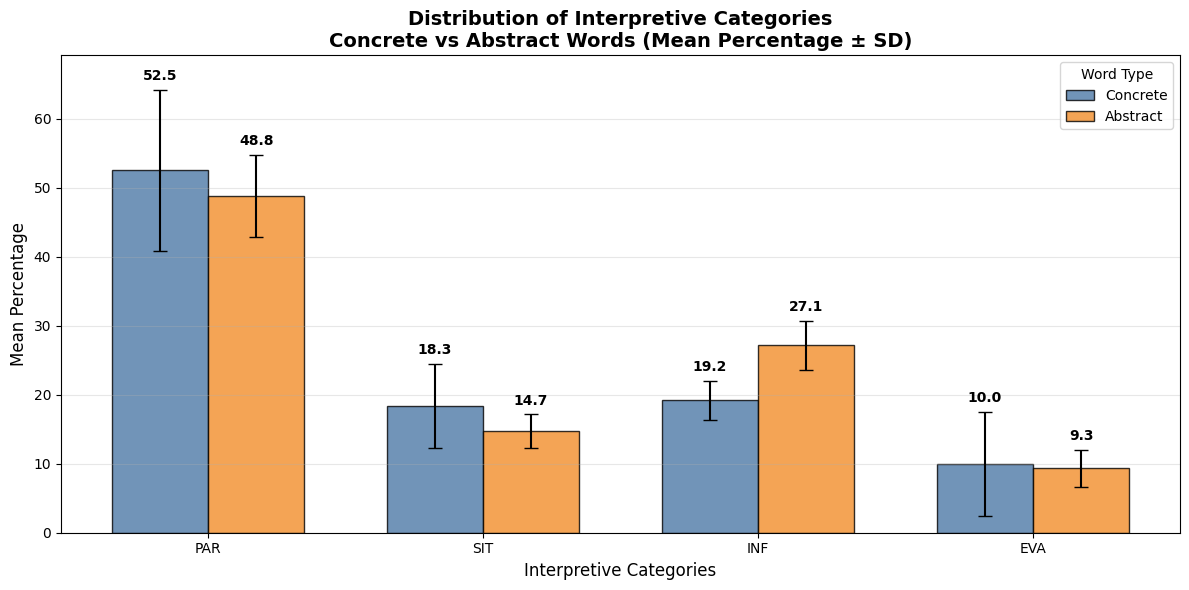

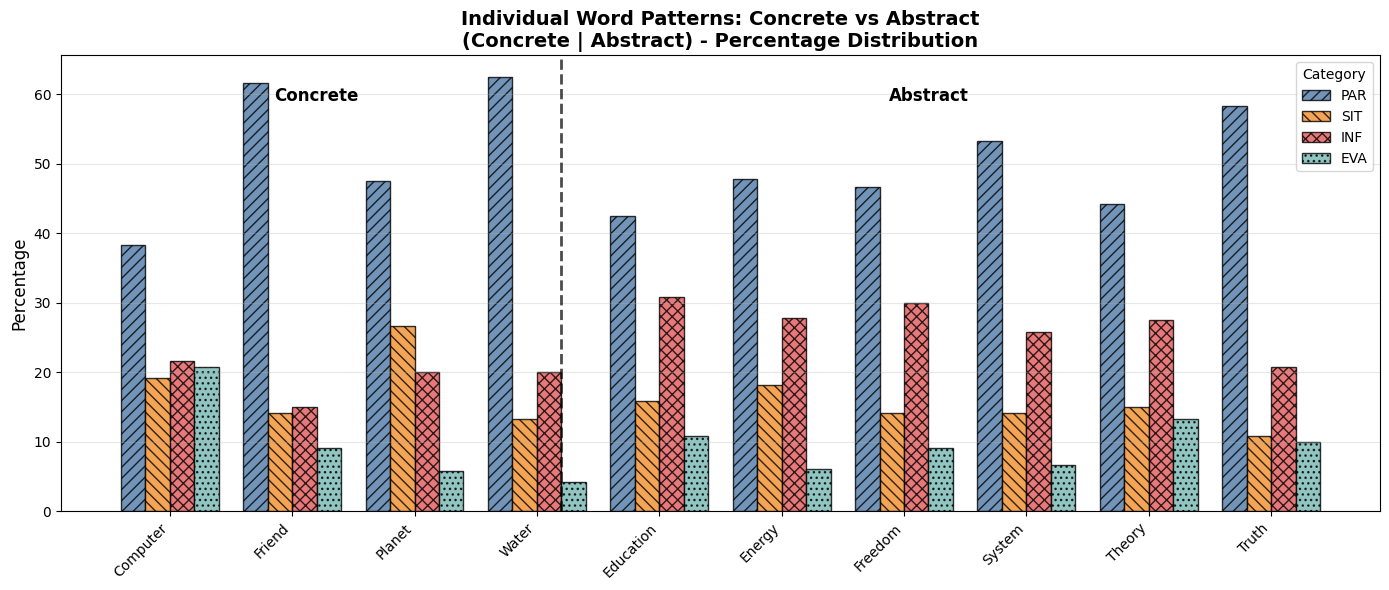

In [72]:
# Visualization for Concrete vs Abstract Words across 4 Categories

# Create summary data by word type
concrete_data = df[df['Type'] == 'Concrete']
abstract_data = df[df['Type'] == 'Abstract']

# Calculate means for each category
categories = ['PAR', 'SIT', 'INF', 'EVA']
concrete_means = [concrete_data[cat].mean() for cat in categories]
abstract_means = [abstract_data[cat].mean() for cat in categories]
concrete_stds = [concrete_data[cat].std() for cat in categories]
abstract_stds = [abstract_data[cat].std() for cat in categories]

print("Mean values by word type (Percentages):") # ADDED (Percentages)
print(f"{'Category':<8} {'Concrete':<12} {'Abstract':<12} {'Difference'}")
print("-" * 45)
for i, cat in enumerate(categories):
    diff = concrete_means[i] - abstract_means[i]
    print(f"{cat:<8} {concrete_means[i]:<12.1f} {abstract_means[i]:<12.1f} {diff:<12.1f}")

print()

# Create the visualization (1: Grouped Bar Chart)
fig, ax = plt.subplots(figsize=(12, 6))

# Set up the bar positions
x = np.arange(len(categories))
width = 0.35

# Create bars
bars1 = ax.bar(x - width/2, concrete_means, width,
               label='Concrete', color='#4e79a7', alpha=0.8,
               edgecolor='black', yerr=concrete_stds, capsize=5)

bars2 = ax.bar(x + width/2, abstract_means, width,
               label='Abstract', color='#f28e2b', alpha=0.8,
               edgecolor='black', yerr=abstract_stds, capsize=5)

# Add value labels on bars
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    height1 = bar1.get_height()
    height2 = bar2.get_height()

    # Add text on top of bars
    ax.text(bar1.get_x() + bar1.get_width()/2., height1 + concrete_stds[i] + 1,
            f'{height1:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.text(bar2.get_x() + bar2.get_width()/2., height2 + abstract_stds[i] + 1,
            f'{height2:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Customization
ax.set_xlabel('Interpretive Categories', fontsize=12)
# EDITED: Changed 'Mean Count' to 'Mean Percentage'
ax.set_ylabel('Mean Percentage', fontsize=12)
# EDITED: Added 'Percentage' to the title
ax.set_title('Distribution of Interpretive Categories\nConcrete vs Abstract Words (Mean Percentage ± SD)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend(title='Word Type', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Set y-axis to start from 0 and give some headroom
max_val = max(max(concrete_means), max(abstract_means))
max_std = max(max(concrete_stds), max(abstract_stds))
ax.set_ylim(0, max_val + max_std + 5)

plt.tight_layout()
plt.show()

# Additional visualization (2: Individual Word Patterns)
fig, ax = plt.subplots(figsize=(14, 6))

# Get the actual words from the dataframe to avoid whitespace issues
concrete_words = df[df['Type'] == 'Concrete']['Word'].tolist()
abstract_words = df[df['Type'] == 'Abstract']['Word'].tolist()
all_words = concrete_words + abstract_words

# Create positions for each word
x_positions = range(len(all_words))
bar_width = 0.2

# Plot each category for each word
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']
hatches = ['///', '\\\\\\', 'xxx', '...']

for i, (cat, color, hatch) in enumerate(zip(categories, colors, hatches)):
    values = []
    for word in all_words:
        # Find the exact word in dataframe (handles whitespace)
        word_data = df[df['Word'] == word]
        if len(word_data) > 0:
            values.append(word_data[cat].iloc[0])
        else:
            # Fallback: try with stripped whitespace
            word_data = df[df['Word'].str.strip() == word.strip()]
            if len(word_data) > 0:
                values.append(word_data[cat].iloc[0])
            else:
                values.append(0)

    # Plot bars for this category
    bar_positions = [x + i * bar_width for x in x_positions]
    bars = ax.bar(bar_positions, values, width=bar_width,
                  label=cat, color=color, alpha=0.8,
                  edgecolor='black', hatch=hatch)

# Add vertical line to separate concrete from abstract
separation_line = len(concrete_words) - 0.5
ax.axvline(x=separation_line, color='black', linestyle='--', linewidth=2, alpha=0.7)

# Customization
ax.set_xticks([x + 1.5 * bar_width for x in x_positions])
ax.set_xticklabels([word.strip() for word in all_words], rotation=45, ha='right')
# EDITED: Changed 'Count' to 'Percentage'
ax.set_ylabel('Percentage', fontsize=12)
# EDITED: Added 'Percentage Distribution' to the title
ax.set_title('Individual Word Patterns: Concrete vs Abstract\n(Concrete | Abstract) - Percentage Distribution',
             fontsize=14, fontweight='bold')
ax.legend(title='Category', loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

# Add section labels
ax.text(len(concrete_words)/2 - 0.5, ax.get_ylim()[1] * 0.9, 'Concrete',
        ha='center', fontweight='bold', fontsize=12)
ax.text(len(concrete_words) + len(abstract_words)/2 - 0.5, ax.get_ylim()[1] * 0.9, 'Abstract',
        ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

###World-Oriented versus Mind-Oriented

In [73]:
df = pd.read_csv('/content/Final Overview_aggregate.csv')
for category in ['PAR', 'SIT', 'INF', 'EVA']:
    df[category] = (df[category] / df['Total']) * 100

# Define mind-oriented vs world-oriented groups manually
mind_oriented = ['Friend', 'Computer', 'Education', 'Freedom', 'System', 'Theory', 'Truth']
world_oriented = ['Planet', 'Water', 'Energy']

print(f"Mind-oriented words (n={len(mind_oriented)}): {mind_oriented}")
print(f"World-oriented words (n={len(world_oriented)}): {world_oriented}")
print()

# Create a new column in the dataframe to label each word as mind or world oriented
df['Orientation'] = df['Word'].apply(lambda x: 'Mind-Oriented' if x.strip() in mind_oriented else 'World-Oriented')

# Function to perform appropriate statistical test with small sample sizes
def compare_groups(group1_data, group2_data, category_name):
    """
    Compare two groups using appropriate statistical test for small samples
    """
    n1, n2 = len(group1_data), len(group2_data)

    # Check normality for both groups
    if n1 >= 3:
        _, p_norm1 = stats.shapiro(group1_data)
    else:
        p_norm1 = 0.01  # Assume non-normal for very small samples

    if n2 >= 3:
        _, p_norm2 = stats.shapiro(group2_data)
    else:
        p_norm2 = 0.01  # Assume non-normal for very small samples

    # Decide on test
    if p_norm1 > 0.05 and p_norm2 > 0.05 and n1 >= 3 and n2 >= 3:
        # Use t-test if both groups are normal and n >= 3
        t_stat, p_val = stats.ttest_ind(group1_data, group2_data)
        test_used = "Independent t-test"
        test_stat = t_stat
    else:
        # Use Mann-Whitney U test for small/non-normal samples
        u_stat, p_val = stats.mannwhitneyu(group1_data, group2_data, alternative='two-sided')
        test_used = "Mann-Whitney U test"
        test_stat = u_stat

    # Calculate descriptive statistics
    mean1, mean2 = np.mean(group1_data), np.mean(group2_data)
    std1, std2 = np.std(group1_data, ddof=1), np.std(group2_data, ddof=1)

    # Calculate effect size (Cohen's d) - corrected formula for unequal groups
    pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
    cohen_d = (mean1 - mean2) / pooled_std if pooled_std > 0 else 0

    # Effect size interpretation
    if abs(cohen_d) < 0.2:
        effect_interp = "negligible"
    elif abs(cohen_d) < 0.5:
        effect_interp = "small"
    elif abs(cohen_d) < 0.8:
        effect_interp = "medium"
    else:
        effect_interp = "large"

    return {
        'test_used': test_used,
        'test_statistic': test_stat,
        'p_value': p_val,
        'mean_mind': mean1,
        'mean_world': mean2,
        'std_mind': std1,
        'std_world': std2,
        'cohen_d': cohen_d,
        'effect_interpretation': effect_interp,
        'normality_mind': p_norm1,
        'normality_world': p_norm2
    }

# Perform tests for each category
categories = ['PAR', 'SIT', 'INF', 'EVA']
results = {}

print("STATISTICAL COMPARISONS")
print("-" * 40)

for category in categories:
    # Extract data for each group
    mind_data = df[df['Orientation'] == 'Mind-Oriented'][category].values
    world_data = df[df['Orientation'] == 'World-Oriented'][category].values

    # Perform comparison
    result = compare_groups(mind_data, world_data, category)
    results[category] = result

    print(f"\n{category}:")
    print(f"  Test used: {result['test_used']}")
    print(f"  Mind-Oriented: {result['mean_mind']:.1f} ± {result['std_mind']:.1f}")
    print(f"  World-Oriented: {result['mean_world']:.1f} ± {result['std_world']:.1f}")
    print(f"  Test statistic: {result['test_statistic']:.3f}")
    print(f"  p-value: {result['p_value']:.4f}")
    print(f"  Cohen's d: {result['cohen_d']:.3f} ({result['effect_interpretation']})")

    # Significance interpretation
    if result['p_value'] < 0.05:
        direction = "higher" if result['mean_mind'] > result['mean_world'] else "lower"
        print(f"  → Mind-oriented words have {direction} {category} scores (p < 0.05)")
    else:
        print(f"  → No significant difference (p ≥ 0.05)")

# Apply multiple comparisons correction
print(f"\n" + "=" * 60)
print("MULTIPLE COMPARISONS CORRECTION")
print("-" * 40)

p_values = [results[cat]['p_value'] for cat in categories]
corrected_p = np.array(p_values) * len(categories)  # Bonferroni correction
corrected_p = np.minimum(corrected_p, 1.0)  # Cap at 1.0

print("Bonferroni-corrected results:")
for i, category in enumerate(categories):
    original_p = p_values[i]
    corrected = corrected_p[i]
    significance = "***" if corrected < 0.001 else "**" if corrected < 0.01 else "*" if corrected < 0.05 else "ns"

    print(f"  {category}: p = {original_p:.4f} → corrected p = {corrected:.4f} ({significance})")

# Summary table
print(f"\n" + "=" * 60)
print("SUMMARY TABLE")
print("-" * 40)
print(f"{'Category':<8} {'Mind-Orient':<12} {'World-Orient':<13} {'Difference':<12} {'p-value':<10} {'Effect'}")
print("-" * 65)

for category in categories:
    r = results[category]
    diff = r['mean_mind'] - r['mean_world']
    significance = "*" if r['p_value'] < 0.05 else ""

    print(f"{category:<8} {r['mean_mind']:<12.1f} {r['mean_world']:<13.1f} {diff:<12.1f} {r['p_value']:<10.4f} {r['effect_interpretation']}")

Mind-oriented words (n=7): ['Friend', 'Computer', 'Education', 'Freedom', 'System', 'Theory', 'Truth']
World-oriented words (n=3): ['Planet', 'Water', 'Energy']

STATISTICAL COMPARISONS
----------------------------------------

PAR:
  Test used: Mann-Whitney U test
  Mind-Oriented: 49.3 ± 8.7
  World-Oriented: 52.6 ± 8.6
  Test statistic: 6.000
  p-value: 0.3833
  Cohen's d: -0.385 (small)
  → No significant difference (p ≥ 0.05)

SIT:
  Test used: Independent t-test
  Mind-Oriented: 14.8 ± 2.5
  World-Oriented: 19.4 ± 6.7
  Test statistic: -1.688
  p-value: 0.1300
  Cohen's d: -1.165 (large)
  → No significant difference (p ≥ 0.05)

INF:
  Test used: Mann-Whitney U test
  Mind-Oriented: 24.5 ± 5.7
  World-Oriented: 22.6 ± 4.5
  Test statistic: 14.000
  p-value: 0.4928
  Cohen's d: 0.354 (small)
  → No significant difference (p ≥ 0.05)

EVA:
  Test used: Independent t-test
  Mind-Oriented: 11.4 ± 4.6
  World-Oriented: 5.4 ± 1.0
  Test statistic: 2.184
  p-value: 0.0604
  Cohen's d: 1.5

Mean values by word orientation (Percentages):
Category Mind-Orient   World-Orient   Difference
--------------------------------------------------
PAR      49.3          52.6           -3.3        
SIT      14.8          19.4           -4.7        
INF      24.5          22.6           1.9         
EVA      11.4          5.4            6.1         



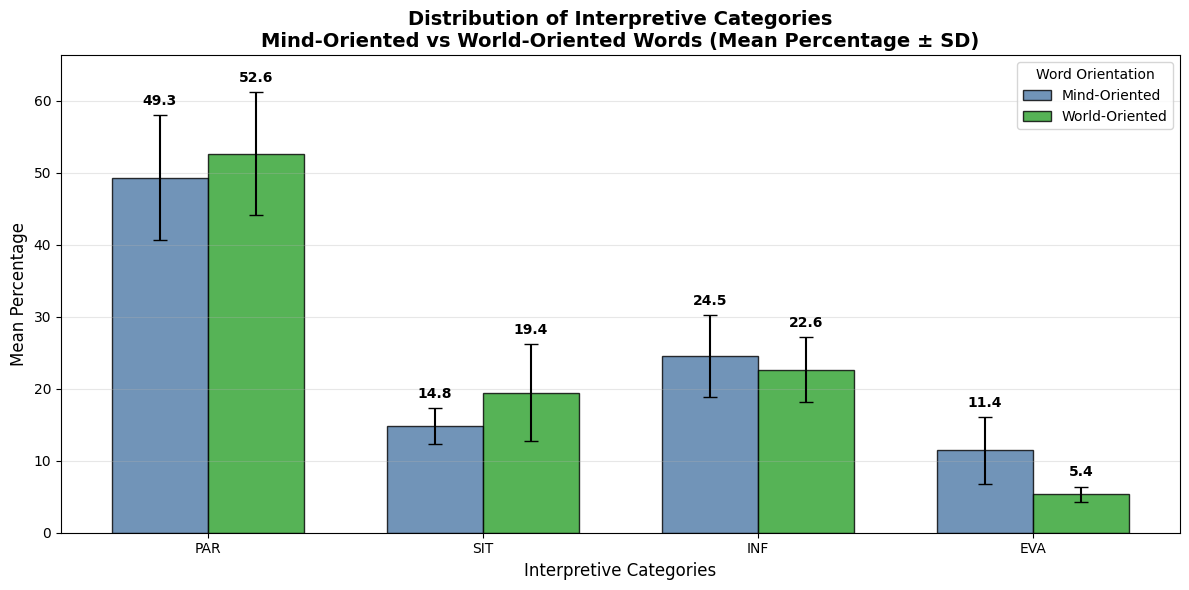

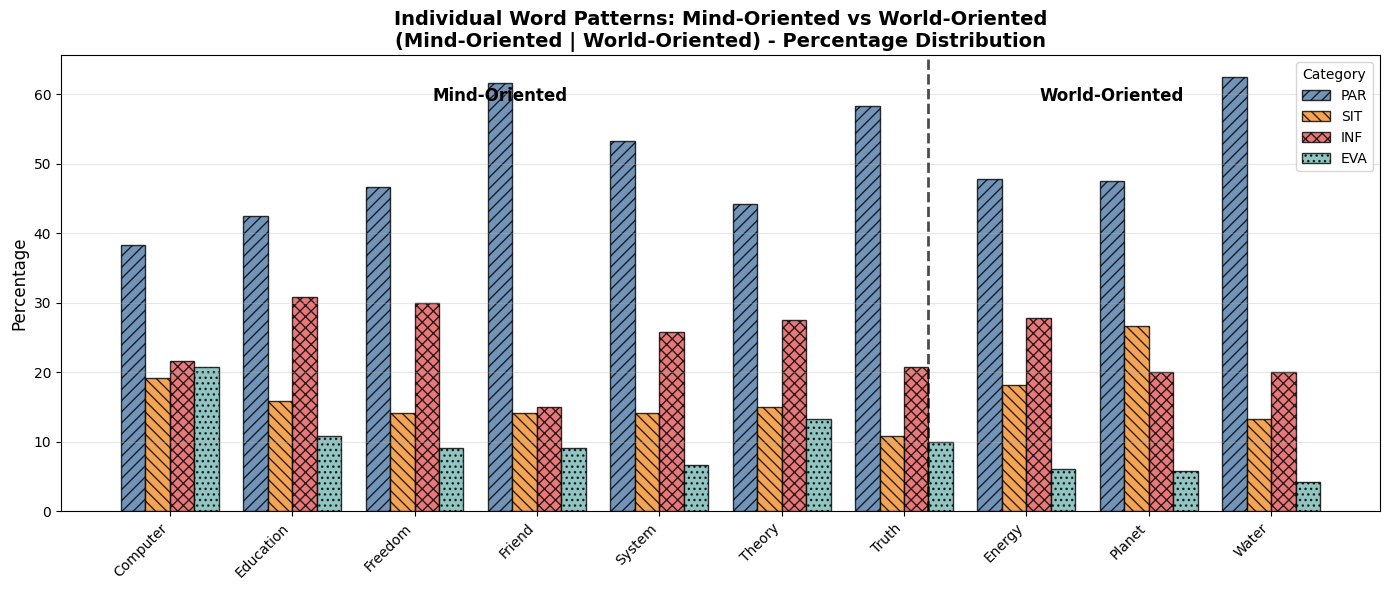


DETAILED BREAKDOWN BY WORD (Percentages):
-----------------------------------------------------------------
Word       Orientation    PAR   SIT   INF   EVA   Total 
-----------------------------------------------------------------
Computer   Mind-Oriented  38.3  19.2  21.7  20.8  100.0 
Education  Mind-Oriented  42.5  15.8  30.8  10.8  100.0 
Energy     World-Oriented 47.8  18.3  27.8  6.1   100.0 
Freedom    Mind-Oriented  46.7  14.2  30.0  9.2   100.0 
Friend     Mind-Oriented  61.7  14.2  15.0  9.2   100.0 
Planet     World-Oriented 47.5  26.7  20.0  5.8   100.0 
System     Mind-Oriented  53.3  14.2  25.8  6.7   100.0 
Theory     Mind-Oriented  44.2  15.0  27.5  13.3  100.0 
Truth      Mind-Oriented  58.3  10.8  20.8  10.0  100.0 
Water      World-Oriented 62.5  13.3  20.0  4.2   100.0 

SUMMARY STATISTICS (Percentages):
-----------------------------------
Mind-oriented words (n=7):
  PAR: 49.3 ± 8.7
  SIT: 14.8 ± 2.5
  INF: 24.5 ± 5.7
  EVA: 11.4 ± 4.6

World-oriented words (n=3):

In [74]:
# Visualization for Mind-Oriented vs World-Oriented Words across 4 Categories

# Create summary data by word orientation
mind_data = df[df['Orientation'] == 'Mind-Oriented']
world_data = df[df['Orientation'] == 'World-Oriented']

# Calculate means for each category
categories = ['PAR', 'SIT', 'INF', 'EVA']
mind_means = [mind_data[cat].mean() for cat in categories]
world_means = [world_data[cat].mean() for cat in categories]
mind_stds = [mind_data[cat].std() for cat in categories]
world_stds = [world_data[cat].std() for cat in categories]

# EDITED: Added (Percentages) to print output
print("Mean values by word orientation (Percentages):")
print(f"{'Category':<8} {'Mind-Orient':<13} {'World-Orient':<14} {'Difference'}")
print("-" * 50)
for i, cat in enumerate(categories):
    diff = mind_means[i] - world_means[i]
    print(f"{cat:<8} {mind_means[i]:<13.1f} {world_means[i]:<14.1f} {diff:<12.1f}")

print()

# Create the visualization (1: Grouped Bar Chart)
fig, ax = plt.subplots(figsize=(12, 6))

# Set up the bar positions
x = np.arange(len(categories))
width = 0.35

# Create bars
bars1 = ax.bar(x - width/2, mind_means, width,
               label='Mind-Oriented', color='#4e79a7', alpha=0.8,
               edgecolor='black', yerr=mind_stds, capsize=5)

bars2 = ax.bar(x + width/2, world_means, width,
               label='World-Oriented', color='#2ca02c', alpha=0.8,
               edgecolor='black', yerr=world_stds, capsize=5)

# Add value labels on bars
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    height1 = bar1.get_height()
    height2 = bar2.get_height()

    # Add text on top of bars
    ax.text(bar1.get_x() + bar1.get_width()/2., height1 + mind_stds[i] + 1,
            f'{height1:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.text(bar2.get_x() + bar2.get_width()/2., height2 + world_stds[i] + 1,
            f'{height2:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Customization
ax.set_xlabel('Interpretive Categories', fontsize=12)
# EDITED: Changed 'Mean Count' to 'Mean Percentage'
ax.set_ylabel('Mean Percentage', fontsize=12)
# EDITED: Added 'Percentage' to the title
ax.set_title('Distribution of Interpretive Categories\nMind-Oriented vs World-Oriented Words (Mean Percentage ± SD)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend(title='Word Orientation', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Set y-axis to start from 0 and give some headroom
max_val = max(max(mind_means), max(world_means))
max_std = max(max(mind_stds), max(world_stds))
ax.set_ylim(0, max_val + max_std + 5)

plt.tight_layout()
plt.show()

# Additional visualization (2: Individual Word Patterns)
fig, ax = plt.subplots(figsize=(14, 6))

# Get the actual words from the dataframe to avoid whitespace issues
mind_words = df[df['Orientation'] == 'Mind-Oriented']['Word'].tolist()
world_words = df[df['Orientation'] == 'World-Oriented']['Word'].tolist()
all_words = mind_words + world_words

# Create positions for each word
x_positions = range(len(all_words))
bar_width = 0.2

# Plot each category for each word
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']
hatches = ['///', '\\\\\\', 'xxx', '...']

for i, (cat, color, hatch) in enumerate(zip(categories, colors, hatches)):
    values = []
    for word in all_words:
        # Find the exact word in dataframe (handles whitespace)
        word_data = df[df['Word'] == word]
        if len(word_data) > 0:
            values.append(word_data[cat].iloc[0])
        else:
            # Fallback: try with stripped whitespace
            word_data = df[df['Word'].str.strip() == word.strip()]
            if len(word_data) > 0:
                values.append(word_data[cat].iloc[0])
            else:
                # Assuming 0 if word not found
                values.append(0)

    # Plot bars for this category
    bar_positions = [x + i * bar_width for x in x_positions]
    bars = ax.bar(bar_positions, values, width=bar_width,
                  label=cat, color=color, alpha=0.8,
                  edgecolor='black', hatch=hatch)

# Add vertical line to separate mind-oriented from world-oriented
separation_line = len(mind_words) - 0.5
ax.axvline(x=separation_line, color='black', linestyle='--', linewidth=2, alpha=0.7)

# Customization
ax.set_xticks([x + 1.5 * bar_width for x in x_positions])
ax.set_xticklabels([word.strip() for word in all_words], rotation=45, ha='right')
# EDITED: Changed 'Count' to 'Percentage'
ax.set_ylabel('Percentage', fontsize=12)
# EDITED: Added 'Percentage Distribution' to the title
ax.set_title('Individual Word Patterns: Mind-Oriented vs World-Oriented\n(Mind-Oriented | World-Oriented) - Percentage Distribution',
             fontsize=14, fontweight='bold')
ax.legend(title='Category', loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

# Add section labels
ax.text(len(mind_words)/2 - 0.5, ax.get_ylim()[1] * 0.9, 'Mind-Oriented',
        ha='center', fontweight='bold', fontsize=12)
ax.text(len(mind_words) + len(world_words)/2 - 0.5, ax.get_ylim()[1] * 0.9, 'World-Oriented',
        ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()


# Create a summary table (Updated print statement)
print("\nDETAILED BREAKDOWN BY WORD (Percentages):") # EDITED: Added (Percentages)
print("-" * 65)
print(f"{'Word':<10} {'Orientation':<14} {'PAR':<5} {'SIT':<5} {'INF':<5} {'EVA':<5} {'Total':<6}")
print("-" * 65)

for _, row in df.iterrows():
    word = row['Word'].strip()
    orientation = row['Orientation']
    # The 'Total' column here might still be raw count unless it was also converted.
    # If 'Total' in the print statement is intended to be a sum of percentages (which should be 100)
    # it's better to just show the percentages or use a pre-calculated total column.
    # Assuming 'Total' is the original total for contextual printing.
    total = row['PAR'] + row['SIT'] + row['INF'] + row['EVA']
    print(f"{word:<10} {orientation:<14} {row['PAR']:<5.1f} {row['SIT']:<5.1f} {row['INF']:<5.1f} {row['EVA']:<5.1f} {total:<6.1f}") # Added .1f for consistency

print("\nSUMMARY STATISTICS (Percentages):")
print("-" * 35)
print(f"Mind-oriented words (n={len(mind_data)}):")
for cat in categories:
    mean_val = mind_data[cat].mean()
    std_val = mind_data[cat].std()
    print(f"  {cat}: {mean_val:.1f} ± {std_val:.1f}")

print(f"\nWorld-oriented words (n={len(world_data)}):")
for cat in categories:
    mean_val = world_data[cat].mean()
    std_val = world_data[cat].std()
    print(f"  {cat}: {mean_val:.1f} ± {std_val:.1f}")

print("=" * 65)

###Linear Regression

In [75]:

df = pd.read_csv('/content/Final Overview_aggregate.csv')
for category in ['PAR', 'SIT', 'INF', 'EVA']:
    df[category] = (df[category] / df['Total']) * 100

# Define groups
concrete = ['Computer', 'Friend', 'Planet', 'Water']
abstract = ['Education', 'Energy', 'Freedom', 'System', 'Theory', 'Truth']
mind_oriented = ['Friend', 'Computer', 'Education', 'Freedom', 'System', 'Theory', 'Truth']
world_oriented = ['Planet', 'Water', 'Energy']

# Create categorical variables
df['Type'] = df['Word'].apply(lambda x: 'Concrete' if x.strip() in concrete else 'Abstract')
df['Orientation'] = df['Word'].apply(lambda x: 'Mind-Oriented' if x.strip() in mind_oriented else 'World-Oriented')

# Rename INF to avoid conflict with 'inf' keyword
df = df.rename(columns={'INF': 'INF_score'})

# Ensure categorical variables are treated properly
df['Type'] = df['Type'].astype('category')
df['Orientation'] = df['Orientation'].astype('category')

# Updated category list
categories = ['PAR', 'SIT', 'INF_score', 'EVA']

# Run regression for each category
for category in categories:
    print(f"\n{'='*70}")
    print(f"REGRESSION FOR {category}")
    print('='*70)
    model = smf.ols(f"{category} ~ Type * Orientation", data=df).fit()
    print(model.summary())
    print()


REGRESSION FOR PAR
                            OLS Regression Results                            
Dep. Variable:                    PAR   R-squared:                       0.095
Model:                            OLS   Adj. R-squared:                 -0.358
Method:                 Least Squares   F-statistic:                    0.2098
Date:                Wed, 05 Nov 2025   Prob (F-statistic):              0.886
Time:                        12:22:47   Log-Likelihood:                -34.331
No. Observations:                  10   AIC:                             76.66
Df Residuals:                       6   BIC:                             77.87
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

##Operationalising Lexical and Contextual Contributions

This section analyzes how words differ in Minimal vs. Substantial Elaboration. It groups words into superordinate categories, calculates percentages, and visualizes distributions per word. Statistical tests (chi-square, t-test, Mann-Whitney U) assess overall patterns, category-specific differences, and whether lexical orientation (Mind- vs World-Oriented) or abstractness (Concrete vs Abstract) influences elaboration. Outputs include plots, summary tables, and effect sizes for a clear, data-driven overview of how lexical and contextual factors shape elaboration patterns.

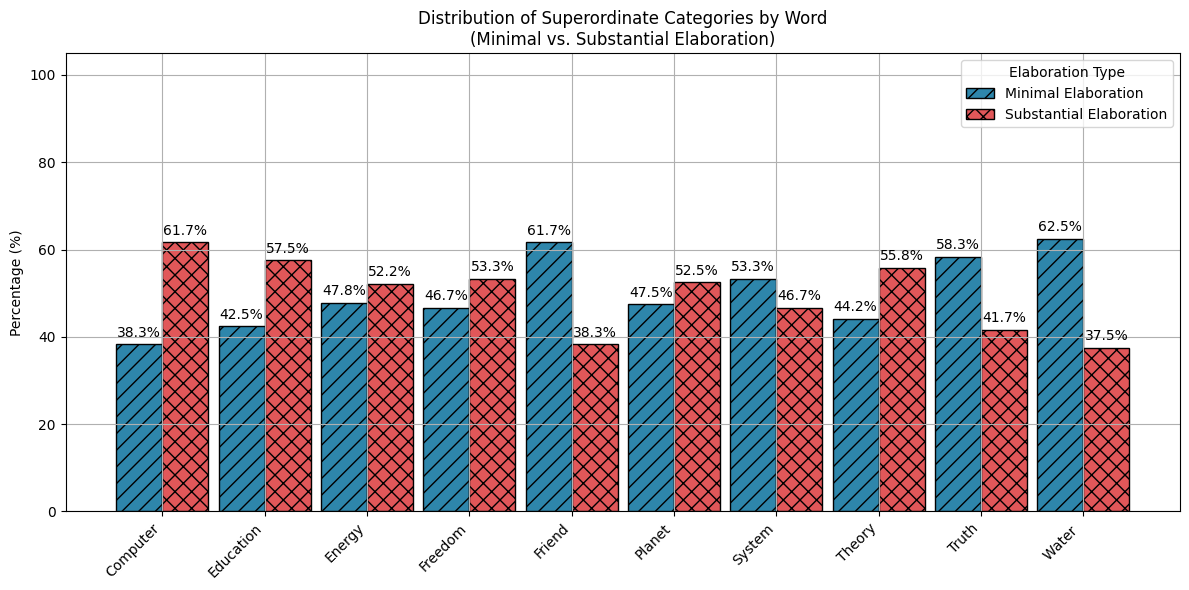


Superordinate category percentages:
           Minimal Elaboration  Substantial Elaboration
Word                                                   
Computer               38.3000                  61.7000
Education              42.5000                  57.5000
Energy                 47.8000                  52.2000
Freedom                46.7000                  53.3000
Friend                 61.7000                  38.3000
Planet                 47.5000                  52.5000
System                 53.3000                  46.7000
Theory                 44.2000                  55.8000
Truth                  58.3000                  41.7000
Water                  62.5000                  37.5000


In [76]:
# Load your data
df = pd.read_csv('/content/Final Overview_aggregate.csv')

# Create new superordinate categories for elaboration
df_super = df.copy()
df_super['Minimal Elaboration'] = df_super['PAR']
df_super['Substantial Elaboration'] = df_super['SIT'] + df_super['INF'] + df_super['EVA']

# Convert to percentage for the two superordinate categories
super_percent = df_super.set_index('Word')[["Minimal Elaboration", "Substantial Elaboration"]].div(
    df_super.set_index('Word')[["Minimal Elaboration", "Substantial Elaboration"]].sum(axis=1), axis=0
) * 100

# Plot the superordinate categories
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.45  # Wider bars to improve readability
x = range(len(super_percent))

# Define categories, hatching, and colors
super_categories = ["Minimal Elaboration", "Substantial Elaboration"]
super_hatches = ["//", "xx"]
super_colors = ["#2E86AB", "#E15759"]  # Distinct colors for clarity

# Plot each superordinate category with percentages on top
for i, (cat, hatch, color) in enumerate(zip(super_categories, super_hatches, super_colors)):
    bars = ax.bar(
        [p + i * bar_width for p in x],
        super_percent[cat],
        width=bar_width,
        label=cat,
        color=color,
        edgecolor="black",
        hatch=hatch
    )
    # Add percentage labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f'{height:.1f}%',
            ha='center',
            va='bottom',
            fontsize=10
        )

# Labeling
ax.set_xticks([p + 0.5 * bar_width for p in x])  # Center x-axis labels
ax.set_xticklabels(super_percent.index, rotation=45, ha="right")
ax.set_ylabel("Percentage (%)")
ax.set_title("Distribution of Superordinate Categories by Word\n(Minimal vs. Substantial Elaboration)")
ax.set_ylim(0, 105)
ax.legend(title="Elaboration Type", loc="upper right")

ax.grid(True)

plt.tight_layout()
plt.show()

# Print actual percentage values for reference
print("\nSuperordinate category percentages:")
print(super_percent.round(1))


In [77]:
# Prepare the data
test_data = df_super[['Word', 'Minimal Elaboration', 'Substantial Elaboration']].copy()

print("Data being tested:")
print(test_data)
print()

# Create 2×10 contingency table: rows = categories, columns = words
contingency_df = test_data.set_index('Word')[['Minimal Elaboration', 'Substantial Elaboration']].T
contingency_table = contingency_df.values

print("Contingency table (2×10):")
print("Rows = Categories, Columns = Words")
print(contingency_df)
print()

# Overall chi-square test
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
n_total = np.sum(contingency_table)
cramers_v = np.sqrt(chi2_stat / (n_total * (min(contingency_table.shape) - 1)))

# Effect size interpretation
if cramers_v < 0.1:
    effect_interp = "negligible"
elif cramers_v < 0.3:
    effect_interp = "small"
elif cramers_v < 0.5:
    effect_interp = "medium"
else:
    effect_interp = "large"

# Variance explained
variance_explained = cramers_v ** 2

# Format p-value - ALWAYS show the actual value
if p_value < 0.001:
    p_formatted = f"{p_value:.6f}***"
elif p_value < 0.01:
    p_formatted = f"{p_value:.4f}**"
elif p_value < 0.05:
    p_formatted = f"{p_value:.4f}*"
else:
    p_formatted = f"{p_value:.4f}"

print(f"Overall Chi-square: χ² = {chi2_stat:.2f} (df = {dof})")
print(f"P-value: {p_formatted}")
print(f"Effect size: Cramér's V = {cramers_v:.3f} ({effect_interp})")
print(f"Variance explained: {variance_explained:.1%}")

# =============================================================================
# CATEGORY-SPECIFIC TESTS: Test each category individually
# =============================================================================

print("\n" + "=" * 50)
print("CATEGORY-SPECIFIC ANALYSIS")
print("=" * 50)

# Test each category individually using goodness-of-fit tests
categories = ['Minimal Elaboration', 'Substantial Elaboration']
category_results = []

for category in categories:
    print(f"\n{category.upper()} - Chi-square goodness-of-fit test")
    print("-" * 40)

    # Get observed frequencies for this category across words
    observed = test_data.set_index('Word')[category].values

    # Expected frequencies (uniform distribution)
    expected_uniform = np.full(len(observed), observed.mean())

    # Chi-square goodness-of-fit test
    chi2_gof, p_gof = chisquare(observed, expected_uniform)

    # Effect size for goodness-of-fit (coefficient of variation)
    cv = np.std(observed) / np.mean(observed) if np.mean(observed) > 0 else 0

    # Interpret effect size
    if cv < 0.1:
        cv_interp = "negligible"
    elif cv < 0.3:
        cv_interp = "small"
    elif cv < 0.5:
        cv_interp = "medium"
    else:
        cv_interp = "large"

    # Format p-value -
    if p_gof < 0.001:
        p_gof_formatted = f"{p_gof:.6f}***"
    elif p_gof < 0.01:
        p_gof_formatted = f"{p_gof:.4f}**"
    elif p_gof < 0.05:
        p_gof_formatted = f"{p_gof:.4f}*"
    else:
        p_gof_formatted = f"{p_gof:.4f}"

    # Interpretation
    if p_gof < 0.05:
        interpretation = "Significant variation across words"
    else:
        interpretation = "No significant variation across words"

    print(f"Observed frequencies: {observed}")
    print(f"Chi-square: χ² = {chi2_gof:.2f}")
    print(f"P-value: {p_gof_formatted}")
    print(f"Coefficient of Variation: {cv:.3f} ({cv_interp})")
    print(f"Interpretation: {interpretation}")

    # Store results
    category_results.append({
        'Category': category,
        'Chi2': chi2_gof,
        'P_value': p_gof_formatted,
        'CV': cv,
        'CV_interp': cv_interp,
        'Interpretation': interpretation
    })

# =============================================================================
# SUMMARY TABLE (Publication Ready)
# =============================================================================

print("\n" + "=" * 70)
print("SUMMARY TABLE")
print("=" * 70)

print("Analysis Type".ljust(25) + "Test".ljust(25) + "Statistic".ljust(20) + "p-value".ljust(12) + "Effect Size".ljust(15) + "Interpretation")
print("-" * 120)

# Overall model
print("Overall Model".ljust(25) + "Chi-square independence".ljust(25) + f"χ² = {chi2_stat:.2f} (df = {dof})".ljust(20) + p_formatted.ljust(12) + f"{cramers_v:.3f}".ljust(15) + f"{effect_interp.title()} effect ({variance_explained:.1%} variance)")

print()
print("Category-Specific Tests".ljust(25))

# Category-specific results
for result in category_results:
    category_short = result['Category'].replace('What is ', '').replace('said', 'SAID').replace('implicated', 'IMPL')
    print("".ljust(25) + f"{category_short}".ljust(25) + f"χ² = {result['Chi2']:.2f}".ljust(20) + result['P_value'].ljust(12) + f"CV = {result['CV']:.3f}".ljust(15) + result['Interpretation'])



Data being tested:
        Word  Minimal Elaboration  Substantial Elaboration
0   Computer                   46                       74
1  Education                   51                       69
2     Energy                   55                       60
3    Freedom                   56                       64
4     Friend                   74                       46
5     Planet                   57                       63
6     System                   64                       56
7     Theory                   53                       67
8      Truth                   70                       50
9     Water                    75                       45

Contingency table (2×10):
Rows = Categories, Columns = Words
Word                     Computer  Education  Energy  Freedom  Friend  Planet  \
Minimal Elaboration            46         51      55       56      74      57   
Substantial Elaboration        74         69      60       64      46      63   

Word                     S

###Checking if lexical orientation influences "minimal elaboration" vs "substantial elaboration" patterns

In [78]:
# Statistical Analysis: Mind-Oriented vs World-Oriented Words for "minimal elaboration" vs "substantial elaboration"
# Run this after creating the superordinate categories

# Define mind-oriented vs world-oriented groups manually
mind_oriented = ['Friend', 'Computer', 'Education', 'Freedom', 'System', 'Theory', 'Truth']
world_oriented = ['Planet', 'Water', 'Energy']

print(f"Mind-oriented words: {mind_oriented}")
print(f"World-oriented words: {world_oriented}")
print()

# Add word orientation to the superordinate dataframe
df_super_orient = df_super.copy()
df_super_orient['Word_Orientation'] = df_super_orient['Word'].apply(
    lambda x: 'Mind-Oriented' if x.strip() in mind_oriented else 'World-Oriented'
)

# Calculate percentages for superordinate categories
super_percent_orient = df_super_orient.set_index('Word')[["Minimal Elaboration", "Substantial Elaboration"]].div(
    df_super_orient.set_index('Word')[["Minimal Elaboration", "Substantial Elaboration"]].sum(axis=1), axis=0) * 100

# Add word orientation to percentage dataframe
super_percent_orient['Word_Orientation'] = df_super_orient.set_index('Word')['Word_Orientation']

print("Data by word orientation:")
print(super_percent_orient.round(1))
print()

# Calculate summary statistics by word orientation
mind_data = super_percent_orient[super_percent_orient['Word_Orientation'] == 'Mind-Oriented']
world_data = super_percent_orient[super_percent_orient['Word_Orientation'] == 'World-Oriented']

print(f"SUMMARY STATISTICS")
print("-" * 40)
print(f"Mind-oriented words (n={len(mind_data)}):")
print(f"  Minimal Elaboration: {mind_data['Minimal Elaboration'].mean():.1f}% ± {mind_data['Minimal Elaboration'].std():.1f}%")
print(f"  Substantial Elaboration: {mind_data['Substantial Elaboration'].mean():.1f}% ± {mind_data['Substantial Elaboration'].std():.1f}%")
print(f"  Range: {mind_data['Minimal Elaboration'].min():.1f}% - {mind_data['Minimal Elaboration'].max():.1f}%")

print(f"\nWorld-oriented words (n={len(world_data)}):")
print(f"  Minimal Elaboration: {world_data['Minimal Elaboration'].mean():.1f}% ± {world_data['Minimal Elaboration'].std():.1f}%")
print(f"  Substantial Elaboration: {world_data['Substantial Elaboration'].mean():.1f}% ± {world_data['Substantial Elaboration'].std():.1f}%")
print(f"  Range: {world_data['Minimal Elaboration'].min():.1f}% - {world_data['Minimal Elaboration'].max():.1f}%")

print(f"\n" + "=" * 70)

# Statistical Testing
print("STATISTICAL TESTING")
print("-" * 40)

# Method 1: Two-sample t-test for "Minimal Elaboration" percentages
print("METHOD 1: Two-sample t-test")
print("Testing: Do mind-oriented and world-oriented words differ in 'Minimal Elaboration' percentages?")

mind_said = mind_data['Minimal Elaboration'].values
world_said = world_data['Minimal Elaboration'].values

# Check normality (Shapiro-Wilk test)
_, p_norm_mind = stats.shapiro(mind_said)
_, p_norm_world = stats.shapiro(world_said)

print(f"\nNormality tests:")
print(f"  Mind-oriented words: p = {p_norm_mind:.4f}")
print(f"  World-oriented words: p = {p_norm_world:.4f}")

if p_norm_mind > 0.05 and p_norm_world > 0.05:
    # Use t-test
    t_stat, p_val_t = ttest_ind(mind_said, world_said)
    test_used = "Independent t-test"
    print(f"  → Both groups normal, using t-test")
else:
    # Use Mann-Whitney U test
    u_stat, p_val_t = mannwhitneyu(mind_said, world_said, alternative='two-sided')
    test_used = "Mann-Whitney U test"
    print(f"  → Non-normal data, using Mann-Whitney U test")

print(f"\n{test_used} results:")
if test_used == "Independent t-test":
    print(f"  t-statistic: {t_stat:.4f}")
else:
    print(f"  U-statistic: {u_stat:.4f}")
print(f"  p-value: {p_val_t:.6f}")

# Effect size (Cohen's d for t-test)
if test_used == "Independent t-test":
    pooled_std = np.sqrt(((len(mind_said) - 1) * np.var(mind_said, ddof=1) +
                         (len(world_said) - 1) * np.var(world_said, ddof=1)) /
                        (len(mind_said) + len(world_said) - 2))
    cohens_d = (np.mean(mind_said) - np.mean(world_said)) / pooled_std
    print(f"  Cohen's d: {cohens_d:.4f}")

    if abs(cohens_d) < 0.2:
        effect_interp = "negligible"
    elif abs(cohens_d) < 0.5:
        effect_interp = "small"
    elif abs(cohens_d) < 0.8:
        effect_interp = "medium"
    else:
        effect_interp = "large"
    print(f"  Effect size: {effect_interp}")

# Method 2: Chi-square test using count data
print(f"\nMETHOD 2: Chi-square test")
print("Testing: Is word orientation (mind/world) independent of said/implicated status?")

# Aggregate counts by word orientation
mind_counts = df_super_orient[df_super_orient['Word_Orientation'] == 'Mind-Oriented'][['Minimal Elaboration', 'Substantial Elaboration']].sum()
world_counts = df_super_orient[df_super_orient['Word_Orientation'] == 'World-Oriented'][['Minimal Elaboration', 'Substantial Elaboration']].sum()

# Create 2x2 contingency table
contingency_2x2 = np.array([
    [mind_counts['Minimal Elaboration'], mind_counts['Substantial Elaboration']],
    [world_counts['Minimal Elaboration'], world_counts['Substantial Elaboration']]
])

print(f"\n2×2 Contingency table:")
contingency_df = pd.DataFrame(contingency_2x2,
                             index=['Mind-Oriented', 'World-Oriented'],
                             columns=['Minimal Elaboration', 'Substantial Elaboration'])
print(contingency_df)

chi2_2x2, p_val_chi2, dof_2x2, expected_2x2 = chi2_contingency(contingency_2x2)

print(f"\nChi-square test results:")
print(f"  Chi-square: {chi2_2x2:.4f}")
print(f"  p-value: {p_val_chi2:.6f}")
print(f"  Degrees of freedom: {dof_2x2}")

# Effect size for 2x2 table (Phi coefficient)
n_total_2x2 = np.sum(contingency_2x2)
phi = np.sqrt(chi2_2x2 / n_total_2x2)
print(f"  Phi coefficient: {phi:.4f}")

if phi < 0.1:
    phi_interp = "negligible"
elif phi < 0.3:
    phi_interp = "small"
elif phi < 0.5:
    phi_interp = "medium"
else:
    phi_interp = "large"
print(f"  Effect size: {phi_interp}")

# Check assumptions for chi-square
min_expected = expected_2x2.min()
print(f"\nAssumption checking:")
print(f"  Minimum expected frequency: {min_expected:.2f}")
print(f"  All expected frequencies ≥ 5: {'Yes' if min_expected >= 5 else 'No - use Fisher exact test'}")



Mind-oriented words: ['Friend', 'Computer', 'Education', 'Freedom', 'System', 'Theory', 'Truth']
World-oriented words: ['Planet', 'Water', 'Energy']

Data by word orientation:
           Minimal Elaboration  Substantial Elaboration Word_Orientation
Word                                                                    
Computer               38.3000                  61.7000    Mind-Oriented
Education              42.5000                  57.5000    Mind-Oriented
Energy                 47.8000                  52.2000   World-Oriented
Freedom                46.7000                  53.3000    Mind-Oriented
Friend                 61.7000                  38.3000    Mind-Oriented
Planet                 47.5000                  52.5000   World-Oriented
System                 53.3000                  46.7000    Mind-Oriented
Theory                 44.2000                  55.8000    Mind-Oriented
Truth                  58.3000                  41.7000    Mind-Oriented
Water                

📊 MIND-ORIENTED vs WORLD-ORIENTED: Minimal Elaboration/IMPLICATED VISUALIZATION


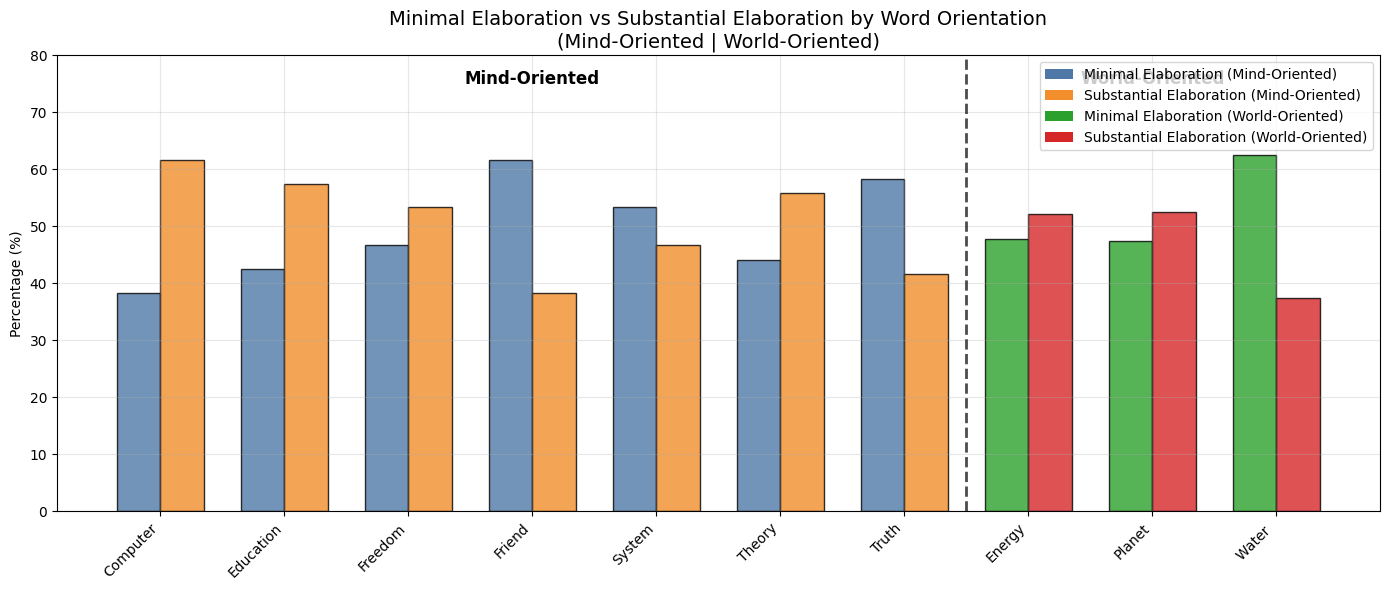

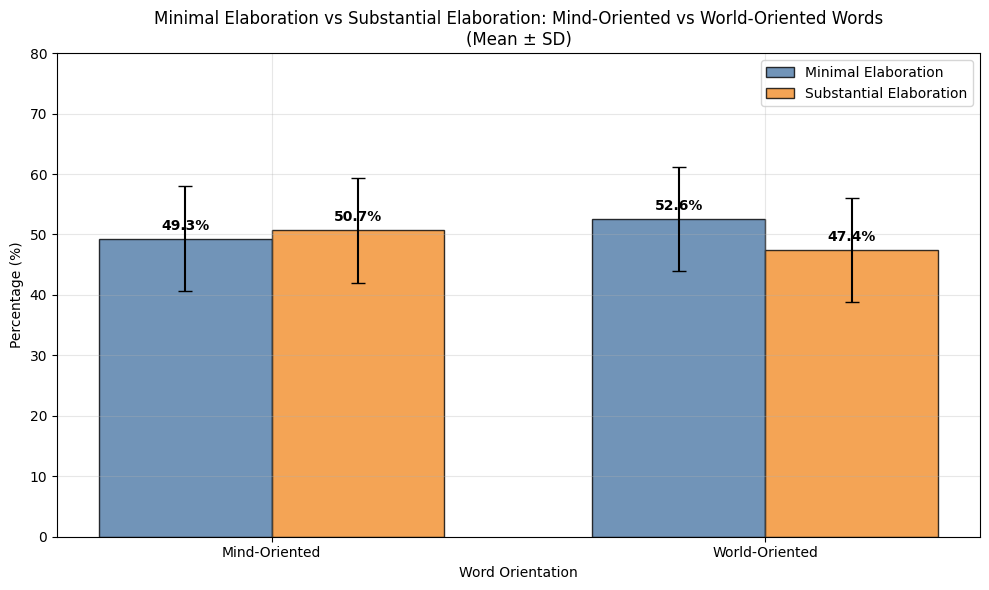

In [79]:
# Visualization: Mind-Oriented vs World-Oriented Words for "minimal elaboration" vs "substantial elaboration"

# Separate words by orientation
words_mind = super_percent_orient[super_percent_orient['Word_Orientation'] == 'Mind-Oriented'].index
words_world = super_percent_orient[super_percent_orient['Word_Orientation'] == 'World-Oriented'].index

# Combine all words in order: mind-oriented first, then world-oriented
all_words = list(words_mind) + list(words_world)
x_positions = range(len(all_words))
bar_width = 0.35

# Plot bars for all words
print("📊 MIND-ORIENTED vs WORLD-ORIENTED: Minimal Elaboration/IMPLICATED VISUALIZATION")
print("=" * 70)

# Create single visualization with all words
fig, ax = plt.subplots(figsize=(14, 6))

# Separate words by orientation but plot on same axes
for i, word in enumerate(all_words):
    # Determine color scheme based on word orientation
    if word in words_mind:
        said_color = '#4e79a7'  # Blue for mind-oriented
        implicated_color = '#f28e2b'  # Orange for mind-oriented
        alpha_val = 0.8
    else:
        said_color = '#2ca02c'  # Green for world-oriented
        implicated_color = '#d62728'  # Red for world-oriented
        alpha_val = 0.8

    # Plot the bars
    ax.bar(i - bar_width/2, super_percent_orient.loc[word, 'Minimal Elaboration'],
           width=bar_width, color=said_color, alpha=alpha_val,
           edgecolor='black', linewidth=1)

    ax.bar(i + bar_width/2, super_percent_orient.loc[word, 'Substantial Elaboration'],
           width=bar_width, color=implicated_color, alpha=alpha_val,
           edgecolor='black', linewidth=1)

# Add vertical line to separate mind-oriented from world-oriented
separation_line = len(words_mind) - 0.5
ax.axvline(x=separation_line, color='black', linestyle='--', linewidth=2, alpha=0.7)

# Add labels and annotations
ax.set_xticks(x_positions)
ax.set_xticklabels(all_words, rotation=45, ha='right')
ax.set_ylabel('Percentage (%)')
ax.set_title('Minimal Elaboration vs Substantial Elaboration by Word Orientation\n(Mind-Oriented | World-Oriented)', fontsize=14)
ax.set_ylim(0, 80)
ax.grid(True, alpha=0.3)

# Create custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4e79a7', label='Minimal Elaboration (Mind-Oriented)'),
    Patch(facecolor='#f28e2b', label='Substantial Elaboration (Mind-Oriented)'),
    Patch(facecolor='#2ca02c', label='Minimal Elaboration (World-Oriented)'),
    Patch(facecolor='#d62728', label='Substantial Elaboration (World-Oriented)')
]
ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.0, 1.0))

# Add text annotations to clarify sections
ax.text(len(words_mind)/2 - 0.5, 75, 'Mind-Oriented', ha='center', fontweight='bold', fontsize=12)
ax.text(len(words_mind) + len(words_world)/2 - 0.5, 75, 'World-Oriented', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# Plot 2: Summary comparison
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for grouped bar chart
word_orientations = ['Mind-Oriented', 'World-Oriented']
said_means = [mind_data['Minimal Elaboration'].mean(), world_data['Minimal Elaboration'].mean()]
implicated_means = [mind_data['Substantial Elaboration'].mean(), world_data['Substantial Elaboration'].mean()]
said_stds = [mind_data['Minimal Elaboration'].std(), world_data['Minimal Elaboration'].std()]
implicated_stds = [mind_data['Substantial Elaboration'].std(), world_data['Substantial Elaboration'].std()]

x = np.arange(len(word_orientations))
width = 0.35

bars1 = ax.bar(x - width/2, said_means, width, label='Minimal Elaboration',
               color='#4e79a7', alpha=0.8, edgecolor='black',
               yerr=said_stds, capsize=5)

bars2 = ax.bar(x + width/2, implicated_means, width, label='Substantial Elaboration',
               color='#f28e2b', alpha=0.8, edgecolor='black',
               yerr=implicated_stds, capsize=5)

# Add value labels on bars
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    height1 = bar1.get_height()
    height2 = bar2.get_height()
    ax.text(bar1.get_x() + bar1.get_width()/2., height1 + 1,
            f'{height1:.1f}%', ha='center', va='bottom', fontweight='bold')
    ax.text(bar2.get_x() + bar2.get_width()/2., height2 + 1,
            f'{height2:.1f}%', ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Word Orientation')
ax.set_ylabel('Percentage (%)')
ax.set_title('Minimal Elaboration vs Substantial Elaboration: Mind-Oriented vs World-Oriented Words\n(Mean ± SD)')
ax.set_xticks(x)
ax.set_xticklabels(word_orientations)
ax.legend()
ax.set_ylim(0, 80)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 70)

###Checking if abstractness influences "minimal elaboration" vs "substantial elaboration" patterns

In [80]:
# Statistical Analysis: Concrete vs Abstract Words for "Minimal Elaboration" vs "Substantial Elaboration"
# Run this after creating the superordinate categories

# Define concrete vs abstract groups manually
concrete = ['Computer', 'Friend', 'Planet', 'Water']
abstract = ['Education', 'Energy', 'Freedom', 'System', 'Theory', 'Truth']

print(f"Concrete words: {concrete}")
print(f"Abstract words: {abstract}")
print()

# Add word type to the superordinate dataframe
df_super_type = df_super.copy()
df_super_type['Word_Type'] = df_super_type['Word'].apply(
    lambda x: 'Concrete' if x.strip() in concrete else 'Abstract'
)

# Calculate percentages for superordinate categories
super_percent_type = df_super_type.set_index('Word')[["Minimal Elaboration", "Substantial Elaboration"]].div(
    df_super_type.set_index('Word')[["Minimal Elaboration", "Substantial Elaboration"]].sum(axis=1), axis=0) * 100

# Add word type to percentage dataframe
super_percent_type['Word_Type'] = df_super_type.set_index('Word')['Word_Type']

print("Data by word type:")
print(super_percent_type.round(1))
print()

# Calculate summary statistics by word type
concrete_data = super_percent_type[super_percent_type['Word_Type'] == 'Concrete']
abstract_data = super_percent_type[super_percent_type['Word_Type'] == 'Abstract']

print(f"SUMMARY STATISTICS")
print("-" * 40)
print(f"Concrete words (n={len(concrete_data)}):")
print(f"  Minimal Elaboration: {concrete_data['Minimal Elaboration'].mean():.1f}% ± {concrete_data['Minimal Elaboration'].std():.1f}%")
print(f"  Substantial Elaboration: {concrete_data['Substantial Elaboration'].mean():.1f}% ± {concrete_data['Substantial Elaboration'].std():.1f}%")
print(f"  Range: {concrete_data['Minimal Elaboration'].min():.1f}% - {concrete_data['Minimal Elaboration'].max():.1f}%")

print(f"\nAbstract words (n={len(abstract_data)}):")
print(f"  Minimal Elaboration: {abstract_data['Minimal Elaboration'].mean():.1f}% ± {abstract_data['Minimal Elaboration'].std():.1f}%")
print(f"  Substantial Elaboration: {abstract_data['Substantial Elaboration'].mean():.1f}% ± {abstract_data['Substantial Elaboration'].std():.1f}%")
print(f"  Range: {abstract_data['Minimal Elaboration'].min():.1f}% - {abstract_data['Minimal Elaboration'].max():.1f}%")

print(f"\n" + "=" * 70)

# Statistical Testing
print("STATISTICAL TESTING")
print("-" * 40)

# Method 1: Two-sample t-test for "Minimal Elaboration" percentages
print("METHOD 1: Two-sample t-test")
print("Testing: Do concrete and abstract words differ in 'Minimal Elaboration' percentages?")

concrete_said = concrete_data['Minimal Elaboration'].values
abstract_said = abstract_data['Minimal Elaboration'].values

# Check normality (Shapiro-Wilk test)
_, p_norm_concrete = stats.shapiro(concrete_said)
_, p_norm_abstract = stats.shapiro(abstract_said)

print(f"\nNormality tests:")
print(f"  Concrete words: p = {p_norm_concrete:.4f}")
print(f"  Abstract words: p = {p_norm_abstract:.4f}")

if p_norm_concrete > 0.05 and p_norm_abstract > 0.05:
    # Use t-test
    t_stat, p_val_t = ttest_ind(concrete_said, abstract_said)
    test_used = "Independent t-test"
    print(f"  → Both groups normal, using t-test")
else:
    # Use Mann-Whitney U test
    u_stat, p_val_t = mannwhitneyu(concrete_said, abstract_said, alternative='two-sided')
    test_used = "Mann-Whitney U test"
    print(f"  → Non-normal data, using Mann-Whitney U test")

print(f"\n{test_used} results:")
if test_used == "Independent t-test":
    print(f"  t-statistic: {t_stat:.4f}")
else:
    print(f"  U-statistic: {u_stat:.4f}")
print(f"  p-value: {p_val_t:.6f}")

# Effect size (Cohen's d for t-test)
if test_used == "Independent t-test":
    pooled_std = np.sqrt(((len(concrete_said) - 1) * np.var(concrete_said, ddof=1) +
                         (len(abstract_said) - 1) * np.var(abstract_said, ddof=1)) /
                        (len(concrete_said) + len(abstract_said) - 2))
    cohens_d = (np.mean(concrete_said) - np.mean(abstract_said)) / pooled_std
    print(f"  Cohen's d: {cohens_d:.4f}")

    if abs(cohens_d) < 0.2:
        effect_interp = "negligible"
    elif abs(cohens_d) < 0.5:
        effect_interp = "small"
    elif abs(cohens_d) < 0.8:
        effect_interp = "medium"
    else:
        effect_interp = "large"
    print(f"  Effect size: {effect_interp}")

# Method 2: Chi-square test using count data
print(f"\nMETHOD 2: Chi-square test")
print("Testing: Is word type (concrete/abstract) independent of said/implicated status?")

# Aggregate counts by word type
concrete_counts = df_super_type[df_super_type['Word_Type'] == 'Concrete'][['Minimal Elaboration', 'Substantial Elaboration']].sum()
abstract_counts = df_super_type[df_super_type['Word_Type'] == 'Abstract'][['Minimal Elaboration', 'Substantial Elaboration']].sum()

# Create 2x2 contingency table
contingency_2x2 = np.array([
    [concrete_counts['Minimal Elaboration'], concrete_counts['Substantial Elaboration']],
    [abstract_counts['Minimal Elaboration'], abstract_counts['Substantial Elaboration']]
])

print(f"\n2×2 Contingency table:")
contingency_df = pd.DataFrame(contingency_2x2,
                             index=['Concrete', 'Abstract'],
                             columns=['Minimal Elaboration', 'Substantial Elaboration'])
print(contingency_df)

chi2_2x2, p_val_chi2, dof_2x2, expected_2x2 = chi2_contingency(contingency_2x2)

print(f"\nChi-square test results:")
print(f"  Chi-square: {chi2_2x2:.4f}")
print(f"  p-value: {p_val_chi2:.6f}")
print(f"  Degrees of freedom: {dof_2x2}")

# Effect size for 2x2 table (Phi coefficient)
n_total_2x2 = np.sum(contingency_2x2)
phi = np.sqrt(chi2_2x2 / n_total_2x2)
print(f"  Phi coefficient: {phi:.4f}")

if phi < 0.1:
    phi_interp = "negligible"
elif phi < 0.3:
    phi_interp = "small"
elif phi < 0.5:
    phi_interp = "medium"
else:
    phi_interp = "large"
print(f"  Effect size: {phi_interp}")

# Check assumptions for chi-square
min_expected = expected_2x2.min()
print(f"\nAssumption checking:")
print(f"  Minimum expected frequency: {min_expected:.2f}")
print(f"  All expected frequencies ≥ 5: {'yes' if min_expected >= 5 else 'No - use Fisher exact test'}")



Concrete words: ['Computer', 'Friend', 'Planet', 'Water']
Abstract words: ['Education', 'Energy', 'Freedom', 'System', 'Theory', 'Truth']

Data by word type:
           Minimal Elaboration  Substantial Elaboration Word_Type
Word                                                             
Computer               38.3000                  61.7000  Concrete
Education              42.5000                  57.5000  Abstract
Energy                 47.8000                  52.2000  Abstract
Freedom                46.7000                  53.3000  Abstract
Friend                 61.7000                  38.3000  Concrete
Planet                 47.5000                  52.5000  Concrete
System                 53.3000                  46.7000  Abstract
Theory                 44.2000                  55.8000  Abstract
Truth                  58.3000                  41.7000  Abstract
Water                  62.5000                  37.5000  Concrete

SUMMARY STATISTICS
------------------------------

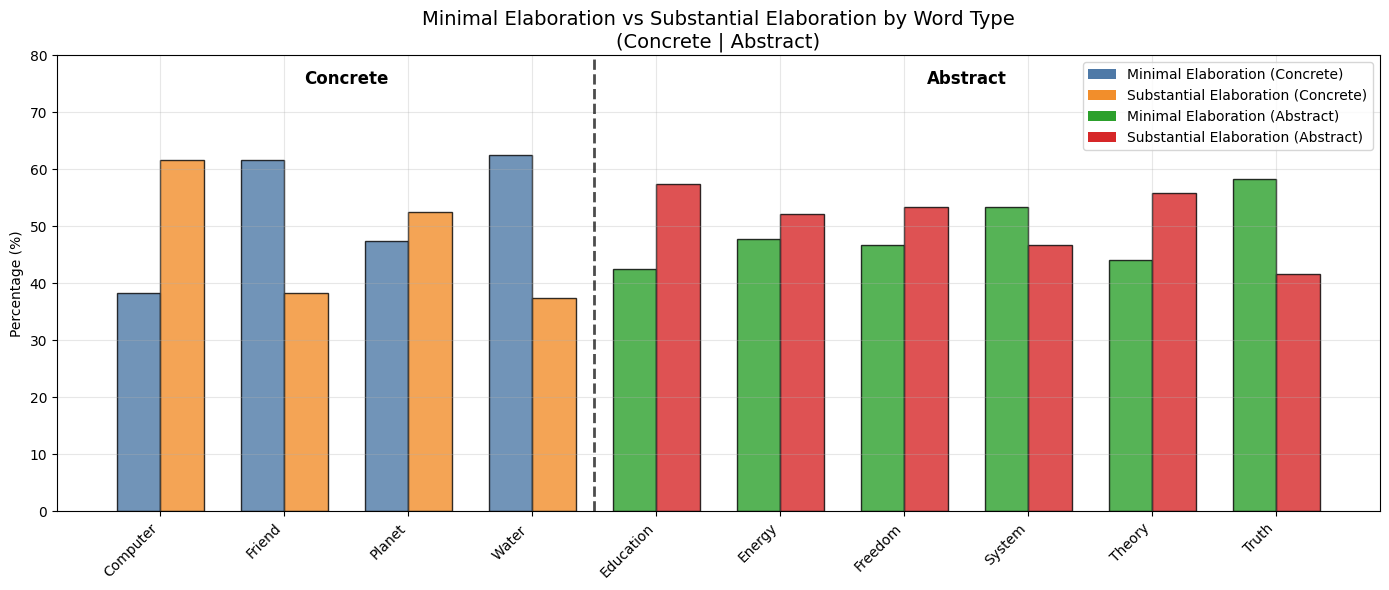

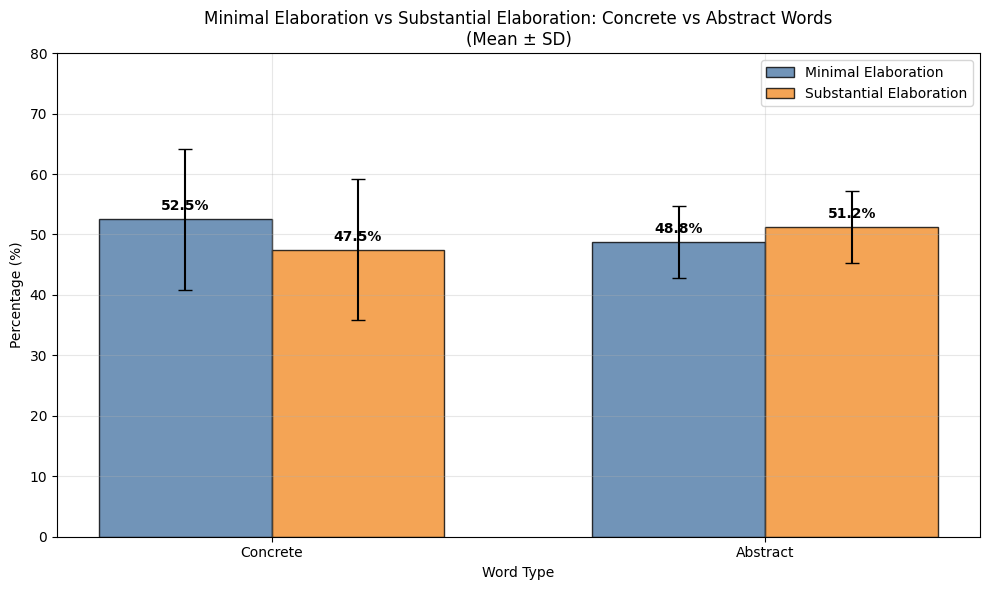

In [81]:
# Visualization: Concrete vs Abstract Words for "Minimal Elaboration" vs "Substantial Elaboration"

# Create single visualization with all words
fig, ax = plt.subplots(figsize=(14, 6))

# Separate words by type but plot on same axes
words_concrete = super_percent_type[super_percent_type['Word_Type'] == 'Concrete'].index
words_abstract = super_percent_type[super_percent_type['Word_Type'] == 'Abstract'].index

# Combine all words in order: concrete first, then abstract
all_words = list(words_concrete) + list(words_abstract)
x_positions = range(len(all_words))
bar_width = 0.35

# Plot bars for all words
for i, word in enumerate(all_words):
    # Determine color scheme based on word type
    if word in words_concrete:
        said_color = '#4e79a7'  # Blue for concrete
        implicated_color = '#f28e2b'  # Orange for concrete
        alpha_val = 0.8
    else:
        said_color = '#2ca02c'  # Green for abstract
        implicated_color = '#d62728'  # Red for abstract
        alpha_val = 0.8

    # Plot the bars
    ax.bar(i - bar_width/2, super_percent_type.loc[word, 'Minimal Elaboration'],
           width=bar_width, color=said_color, alpha=alpha_val,
           edgecolor='black', linewidth=1)

    ax.bar(i + bar_width/2, super_percent_type.loc[word, 'Substantial Elaboration'],
           width=bar_width, color=implicated_color, alpha=alpha_val,
           edgecolor='black', linewidth=1)

# Add vertical line to separate concrete from abstract
separation_line = len(words_concrete) - 0.5
ax.axvline(x=separation_line, color='black', linestyle='--', linewidth=2, alpha=0.7)

# Add labels and annotations
ax.set_xticks(x_positions)
ax.set_xticklabels(all_words, rotation=45, ha='right')
ax.set_ylabel('Percentage (%)')
ax.set_title('Minimal Elaboration vs Substantial Elaboration by Word Type\n(Concrete | Abstract)', fontsize=14)
ax.set_ylim(0, 80)
ax.grid(True, alpha=0.3)

# Create custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4e79a7', label='Minimal Elaboration (Concrete)'),
    Patch(facecolor='#f28e2b', label='Substantial Elaboration (Concrete)'),
    Patch(facecolor='#2ca02c', label='Minimal Elaboration (Abstract)'),
    Patch(facecolor='#d62728', label='Substantial Elaboration (Abstract)')
]
ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.0, 1.0))

# Add text annotations to clarify sections
ax.text(len(words_concrete)/2 - 0.5, 75, 'Concrete', ha='center', fontweight='bold', fontsize=12)
ax.text(len(words_concrete) + len(words_abstract)/2 - 0.5, 75, 'Abstract', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# Plot 2: Summary comparison
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for grouped bar chart
word_types = ['Concrete', 'Abstract']
said_means = [concrete_data['Minimal Elaboration'].mean(), abstract_data['Minimal Elaboration'].mean()]
implicated_means = [concrete_data['Substantial Elaboration'].mean(), abstract_data['Substantial Elaboration'].mean()]
said_stds = [concrete_data['Minimal Elaboration'].std(), abstract_data['Minimal Elaboration'].std()]
implicated_stds = [concrete_data['Substantial Elaboration'].std(), abstract_data['Substantial Elaboration'].std()]

x = np.arange(len(word_types))
width = 0.35

bars1 = ax.bar(x - width/2, said_means, width, label='Minimal Elaboration',
               color='#4e79a7', alpha=0.8, edgecolor='black',
               yerr=said_stds, capsize=5)

bars2 = ax.bar(x + width/2, implicated_means, width, label='Substantial Elaboration',
               color='#f28e2b', alpha=0.8, edgecolor='black',
               yerr=implicated_stds, capsize=5)

# Add value labels on bars
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    height1 = bar1.get_height()
    height2 = bar2.get_height()
    ax.text(bar1.get_x() + bar1.get_width()/2., height1 + 1,
            f'{height1:.1f}%', ha='center', va='bottom', fontweight='bold')
    ax.text(bar2.get_x() + bar2.get_width()/2., height2 + 1,
            f'{height2:.1f}%', ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Word Type')
ax.set_ylabel('Percentage (%)')
ax.set_title('Minimal Elaboration vs Substantial Elaboration: Concrete vs Abstract Words\n(Mean ± SD)')
ax.set_xticks(x)
ax.set_xticklabels(word_types)
ax.legend()
ax.set_ylim(0, 80)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 70)